# AgriPredict
### Machine Learning-Based Crop Yield Prediction Using Environmental and Agricultural Data

**Research question:** Can we predict crop yield using historical agricultural, environmental, and weather data for Kenyan counties?

This notebook builds AgriPredict as a complete data science project — not just a model, but the full pipeline from raw government reports through to a comparison of trained models.

**Pipeline covered in this notebook:**

1. Data Collection
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering (crop yield, weather, soil)
5. Train / Validation / Test split
6. Linear Regression
7. Random Forest
8. XGBoost
9. Model Comparison

**Crops in scope:** Maize, Beans, Sorghum, Green Grams, Irish Potatoes, Tea, Coffee — the five staple/legume crops have full county x year coverage (2019-2024); Tea is grown in a limited number of counties; Coffee has only 3 crop-years of county-level data and is treated as a lower-confidence, supplementary crop throughout.

**Data source:** Kenya National Bureau of Statistics (KNBS) — National Agriculture Production Report 2024 (covers 2019-2023) and National Agriculture Production Report 2025 (covers 2020-2024). County-level tables were extracted directly from these two PDFs.

**Prediction scenario (to avoid data leakage):** This notebook predicts **end-of-season yield** for a county-crop-year using that season's own recorded area planted, plus (once merged in) that season's recorded weather and static soil characteristics. It does **not** use next year's data to predict this year's, and it does not use a crop's own yield as a feature to predict itself.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import os

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")


## 2. Data Collection

The five staple/legume crops (Maize, Beans, Sorghum, Green Grams, Irish Potatoes) were extracted from the KNBS reports as `county, year, crop, area_ha, production_tons` tables. Tea and Coffee have their own structure and are loaded separately below.


In [2]:
crops = ["maize", "beans", "sorghum", "green_grams", "irish_potatoes"]
crop_dfs = {}

for crop in crops:
    df = pd.read_csv(f"DATA/{crop}.csv")
    crop_dfs[crop] = df
    print(crop, df.shape)


maize (282, 5)
beans (254, 5)
sorghum (252, 5)
green_grams (208, 5)
irish_potatoes (168, 5)


### 2.1 Rename columns so each crop keeps its identity after merging

In [3]:
for crop, df in crop_dfs.items():
    df.rename(columns={
        "area_ha": f"{crop}_area_ha",
        "production_tons": f"{crop}_production_tons",
    }, inplace=True)
    if "crop" in df.columns:
        df.drop(columns=["crop"], inplace=True)

crop_dfs["maize"].head()


,county,year,maize_area_ha,maize_production_tons
0,Baringo,2019,45171.0,70810.0
1,Baringo,2020,47437.0,68374.0
2,Baringo,2021,34709.0,59169.0
3,Baringo,2022,37894.0,50820.0
4,Baringo,2023,42501.0,94877.0


### 2.2 Merge the five crops into one wide table, keyed on county + year

In [4]:
wide = crop_dfs["maize"]
for crop in crops[1:]:
    wide = wide.merge(crop_dfs[crop], on=["county", "year"], how="outer")

print(wide.shape)
wide.head()


(282, 12)


,county,year,maize_area_ha,maize_production_tons,beans_area_ha,beans_production_tons,sorghum_area_ha,sorghum_production_tons,green_grams_area_ha,green_grams_production_tons,irish_potatoes_area_ha,irish_potatoes_production_tons
0,Baringo,2019,45171.0,70810.0,21020.0,19977.0,1028.0,1209.0,684.0,494.0,3733.0,39084.0
1,Baringo,2020,47437.0,68374.0,20914.0,24647.0,1467.0,2261.0,1055.0,980.0,3597.0,39207.0
2,Baringo,2021,34709.0,59169.0,19669.0,16289.0,1448.0,562.0,659.0,732.0,3363.0,45215.0
3,Baringo,2022,37894.0,50820.0,23804.0,21616.0,1590.0,557.0,739.0,530.0,3504.0,29998.0
4,Baringo,2023,42501.0,94877.0,23677.0,22501.0,1666.0,1822.0,751.0,901.0,3565.0,37205.0


### 2.3 Load Tea and Coffee, fix county name inconsistencies, then merge

Tea and Coffee were extracted with a different parser (simpler table structure), which let a few county name variants slip through unnormalized (e.g. `"Muranga"` vs `"Murang'a"`). We fix these **before** merging, since fixing them after would leave crop data and tea/coffee data on two separate rows for the same real county.


In [5]:
fix_map = {
    "Muranga": "Murang'a",
    "Tharaka - Nithi": "Tharaka Nithi",
    "Trans-Nzoia": "Trans Nzoia",
}

tea = pd.read_csv("DATA/tea_production.csv")
tea["county"] = tea["county"].replace(fix_map)
tea.rename(columns={
    "made_tea_kg": "tea_made_tea_kg",
    "green_leaf_tea_kg": "tea_green_leaf_tea_kg",
}, inplace=True)
if "crop" in tea.columns:
    tea.drop(columns=["crop"], inplace=True)

wide = wide.merge(tea, on=["county", "year"], how="outer")
print(wide.shape)


(294, 14)


In [6]:
coffee = pd.read_csv("DATA/coffee_area.csv")
coffee["county"] = coffee["county"].replace(fix_map)
# coffee's year comes as a crop-year string like "2021/22" -> map to its ending calendar year
coffee["year"] = coffee["crop_year"].apply(lambda s: 2000 + int(s.split("/")[1]))
coffee.rename(columns={"total_area_ha": "coffee_total_area_ha"}, inplace=True)

wide = wide.merge(coffee[["county", "year", "coffee_total_area_ha"]], on=["county", "year"], how="outer")
print(wide.shape)


(294, 15)


### 2.4 Confirm county names are now clean (49 expected: 47 counties + 2 genuinely combined tea regions)

In [7]:
counties = sorted(wide["county"].unique())
print(len(counties), "distinct county values")
counties


49 distinct county values


['Baringo',
 'Bomet',
 'Bungoma',
 'Busia',
 'Elgeyo Marakwet',
 'Embu',
 'Garissa',
 'Homa Bay',
 'Isiolo',
 'Kajiado',
 'Kakamega',
 'Kakamega/Vihiga',
 'Kericho',
 'Kiambu',
 'Kilifi',
 'Kirinyaga',
 'Kisii',
 'Kisumu',
 'Kitui',
 'Kwale',
 'Laikipia',
 'Lamu',
 'Machakos',
 'Makueni',
 'Mandera',
 'Marsabit',
 'Meru',
 'Migori',
 'Mombasa',
 "Murang'a",
 'Nairobi',
 'Nakuru',
 'Nandi',
 'Narok',
 'Nyamira',
 'Nyandarua',
 'Nyeri',
 'Samburu',
 'Siaya',
 'Taita Taveta',
 'Tana River',
 'Tharaka Nithi',
 'Trans Nzoia',
 'Trans-Nzoia/Bungoma',
 'Turkana',
 'Uasin Gishu',
 'Vihiga',
 'Wajir',
 'West Pokot']

## 3. Data Cleaning

Fill missing values with 0 only where a zero is actually true — a county that doesn't grow a given crop. Tea and Coffee are left as `NaN` where data is genuinely absent, since filling those with 0 would falsely claim "zero production" for counties/years that were simply never reported.


In [8]:
crop_cols = [
    "maize_area_ha", "maize_production_tons",
    "beans_area_ha", "beans_production_tons",
    "sorghum_area_ha", "sorghum_production_tons",
    "green_grams_area_ha", "green_grams_production_tons",
    "irish_potatoes_area_ha", "irish_potatoes_production_tons",
]
wide[crop_cols] = wide[crop_cols].fillna(0)
# tea_made_tea_kg, tea_green_leaf_tea_kg, coffee_total_area_ha stay as NaN intentionally


### 3.1 Structure check

In [9]:
wide.info()

<class 'pandas.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   county                          294 non-null    str    
 1   year                            294 non-null    int64  
 2   maize_area_ha                   294 non-null    float64
 3   maize_production_tons           294 non-null    float64
 4   beans_area_ha                   294 non-null    float64
 5   beans_production_tons           294 non-null    float64
 6   sorghum_area_ha                 294 non-null    float64
 7   sorghum_production_tons         294 non-null    float64
 8   green_grams_area_ha             294 non-null    float64
 9   green_grams_production_tons     294 non-null    float64
 10  irish_potatoes_area_ha          294 non-null    float64
 11  irish_potatoes_production_tons  294 non-null    float64
 12  tea_made_tea_kg                 100 non-null   

In [10]:
wide.describe()

,year,maize_area_ha,maize_production_tons,beans_area_ha,beans_production_tons,sorghum_area_ha,sorghum_production_tons,green_grams_area_ha,green_grams_production_tons,irish_potatoes_area_ha,irish_potatoes_production_tons,tea_made_tea_kg,tea_green_leaf_tea_kg,coffee_total_area_ha
count,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,1.000000e+02,8.500000e+01,87.000000
mean,2021.500000,45919.397959,76405.602041,24326.275510,15455.476190,4521.030612,4413.071429,5738.336735,3117.363946,4412.809524,40705.408163,3.270003e+07,1.405575e+08,3832.004598
std,1.710737,39617.940422,97936.081519,24824.320077,16370.521303,11207.530681,13945.031780,18264.817892,10950.989979,9555.322334,100272.484092,3.348655e+07,1.468383e+08,4647.549397
min,2019.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.530600e+05,4.050505e+06,5.400000
25%,2020.000000,11742.000000,10281.000000,316.500000,156.250000,39.250000,22.250000,0.000000,0.000000,0.000000,0.000000,4.370611e+06,1.877060e+07,339.100000
50%,2021.500000,34845.500000,44714.000000,20423.000000,12528.500000,405.500000,438.500000,88.500000,39.000000,23.000000,193.000000,2.129941e+07,9.209708e+07,1999.200000
75%,2023.000000,71704.000000,92304.000000,35987.000000,24185.750000,2141.500000,2230.250000,1025.250000,899.000000,3064.250000,27092.250000,4.245329e+07,1.814742e+08,6983.000000
max,2024.000000,158761.000000,489056.000000,131624.000000,99926.000000,70509.000000,162004.000000,122902.000000,87448.000000,49981.000000,657091.000000,1.151125e+08,4.892281e+08,20369.000000


### 3.2 Missingness by column

In [11]:
(wide.isna().mean().sort_values(ascending=False) * 100).round(2)

tea_green_leaf_tea_kg             71.09
coffee_total_area_ha              70.41
tea_made_tea_kg                   65.99
maize_production_tons              0.00
county                             0.00
year                               0.00
maize_area_ha                      0.00
sorghum_area_ha                    0.00
beans_production_tons              0.00
beans_area_ha                      0.00
sorghum_production_tons            0.00
irish_potatoes_area_ha             0.00
green_grams_production_tons        0.00
green_grams_area_ha                0.00
irish_potatoes_production_tons     0.00
dtype: float64

### 3.3 Check for physically impossible rows (production > 0 with 0 area planted)

In [12]:
for crop in crops:
    bad = wide[(wide[f"{crop}_area_ha"] == 0) & (wide[f"{crop}_production_tons"] > 0)]
    print(crop, "suspicious rows:", len(bad))


maize suspicious rows: 0
beans suspicious rows: 0
sorghum suspicious rows: 0
green_grams suspicious rows: 0
irish_potatoes suspicious rows: 0


### 3.4 Engineer yield — the actual target variable

Area and production alone aren't what the project predicts — **yield (tonnes/hectare)** is. It's computed here, with any division-by-zero results cleaned to `NaN` rather than `inf`.


In [13]:
for crop in crops:
    wide[f"{crop}_yield_t_per_ha"] = wide[f"{crop}_production_tons"] / wide[f"{crop}_area_ha"]

wide.replace([np.inf, -np.inf], np.nan, inplace=True)

wide[["county", "year"] + [f"{c}_yield_t_per_ha" for c in crops]].head(10)


,county,year,maize_yield_t_per_ha,beans_yield_t_per_ha,sorghum_yield_t_per_ha,green_grams_yield_t_per_ha,irish_potatoes_yield_t_per_ha
0,Baringo,2019,1.567599,0.950381,1.176070,0.722222,10.469863
1,Baringo,2020,1.441364,1.178493,1.541241,0.928910,10.899917
2,Baringo,2021,1.704716,0.828156,0.388122,1.110774,13.444841
3,Baringo,2022,1.341109,0.908083,0.350314,0.717185,8.561073
4,Baringo,2023,2.232347,0.950332,1.093637,1.199734,10.436185
5,Baringo,2024,1.769138,0.892287,1.312000,1.052216,11.364238
6,Bomet,2019,2.167537,1.319741,1.927687,NaN,9.889816
7,Bomet,2020,1.721348,1.371377,2.272517,NaN,10.129529
8,Bomet,2021,1.449728,0.966091,2.074780,NaN,10.300624
9,Bomet,2022,1.568540,1.014352,1.203151,NaN,11.696856


### 3.5 Save the cleaned, feature-engineered dataset

In [14]:
os.makedirs("DATA", exist_ok=True)
wide = wide.sort_values(["county", "year"]).reset_index(drop=True)
wide.to_csv("DATA/agripredict_wide.csv", index=False)
print("Saved:", wide.shape)


Saved: (294, 20)


## 4. Exploratory Data Analysis (EDA)

### 4.1 Yield trend over time — grains/legumes vs. potatoes (different scale, split for readability)

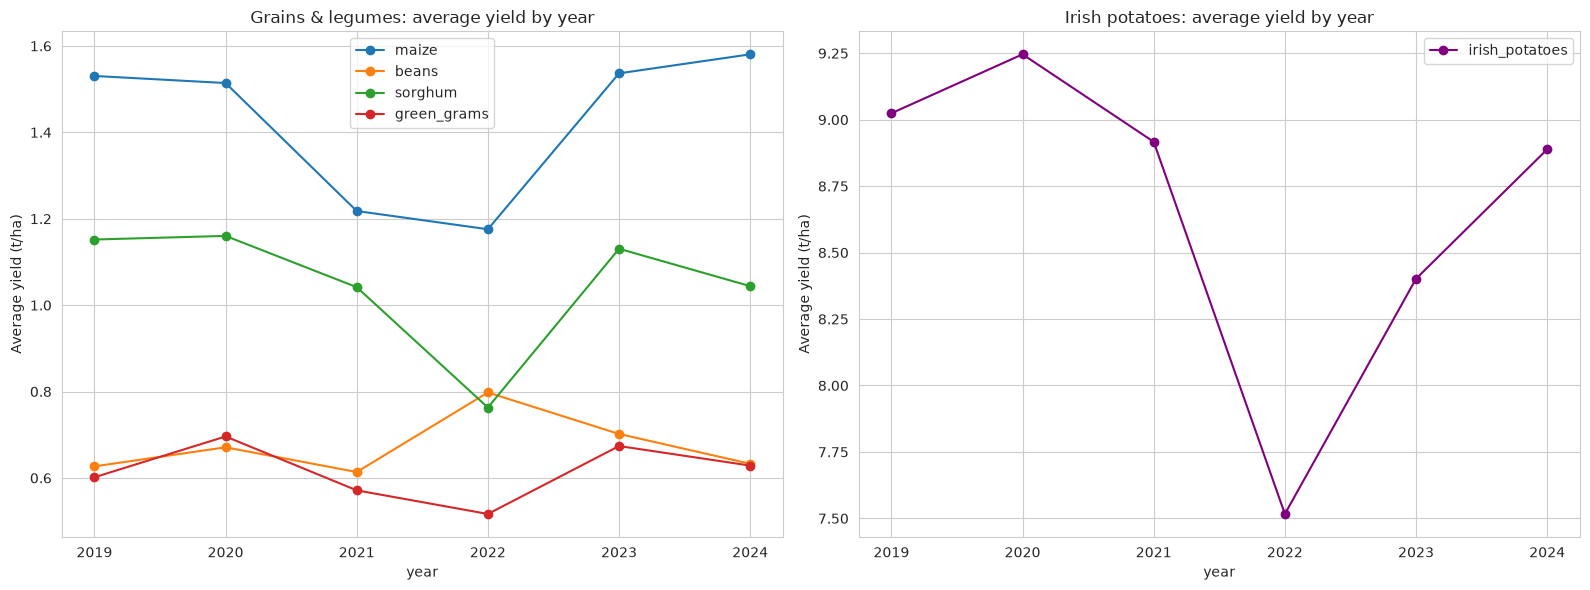

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for crop in ["maize", "beans", "sorghum", "green_grams"]:
    wide.groupby("year")[f"{crop}_yield_t_per_ha"].mean().plot(ax=axes[0], label=crop, marker="o")
axes[0].legend()
axes[0].set_title("Grains & legumes: average yield by year")
axes[0].set_ylabel("Average yield (t/ha)")

wide.groupby("year")["irish_potatoes_yield_t_per_ha"].mean().plot(ax=axes[1], label="irish_potatoes", marker="o", color="purple")
axes[1].legend()
axes[1].set_title("Irish potatoes: average yield by year")
axes[1].set_ylabel("Average yield (t/ha)")

plt.tight_layout()
plt.show()


### 2022 Explanation
- The short rains that were expected in late 2021 (October to December) failed which was a third consecutive below-average season across pastoral and marginal agricultural areas of eastern and northern Kenya
- Drought affected 23 counties in Kenya's arid and semi-arid lands by March 2022, with 3.5 million people facing acute food insecurity. National maize production for that period dropped 23% year-on-year, with most regions receiving at least 30% less rainfall than normal and corn wilting in arid and semi-arid areas


### 4.2 Yield variation across counties — maize as the example

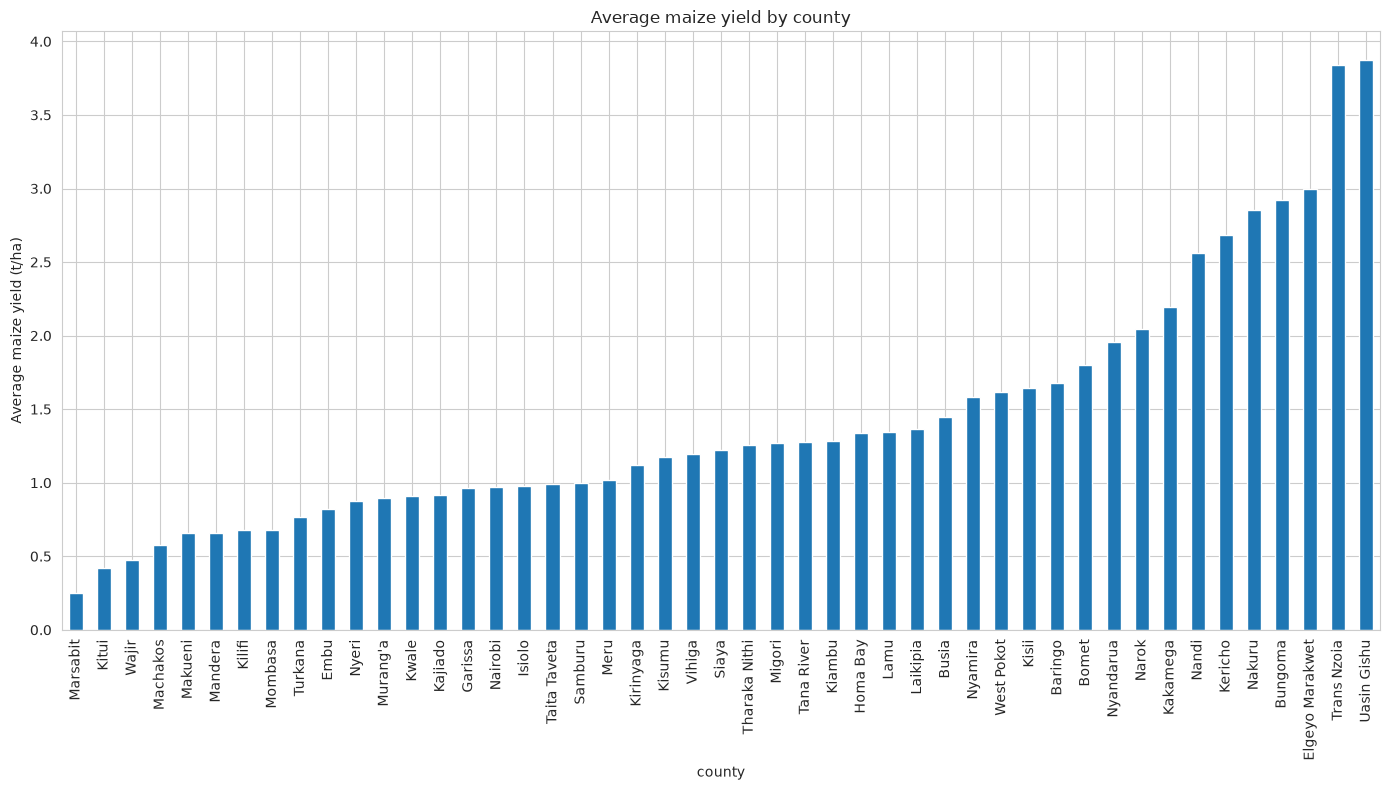

In [16]:
plt.figure(figsize=(14, 8))
wide.groupby("county")["maize_yield_t_per_ha"].mean().sort_values().dropna().plot(kind="bar")
plt.ylabel("Average maize yield (t/ha)")
plt.title("Average maize yield by county")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### 4.3 Yield distribution per crop

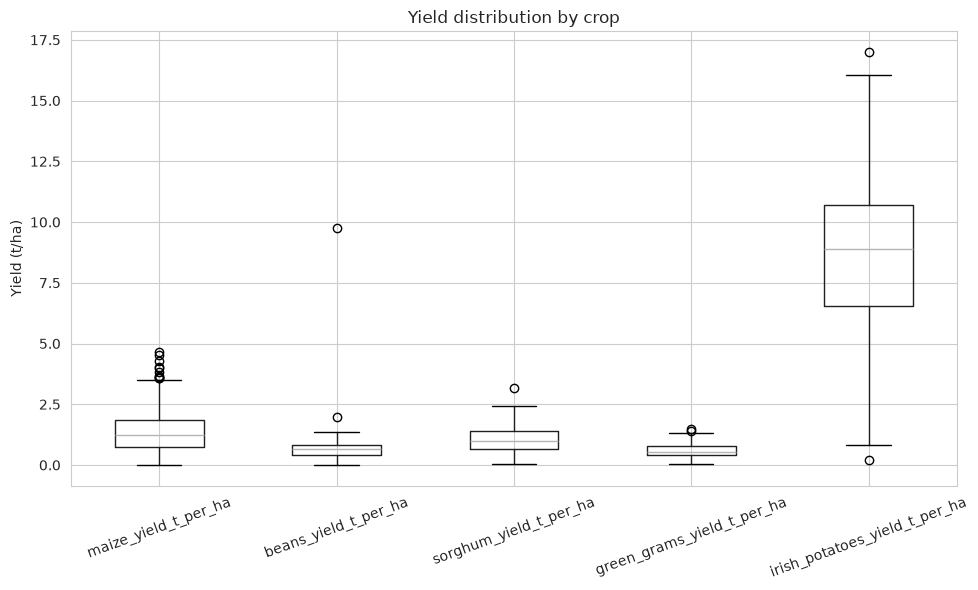

In [17]:
yield_cols = [f"{c}_yield_t_per_ha" for c in crops]
plt.figure(figsize=(10, 6))
wide[yield_cols].boxplot()
plt.ylabel("Yield (t/ha)")
plt.title("Yield distribution by crop")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### What this chart shows

This boxplot shows the spread of yield (t/ha) for each crop — not just the average, but the typical range and any outliers.

- **Irish potatoes** yield far more than the other crops (7.5–10 t/ha typical range) — expected, since potatoes are a high-yield tuber crop, not a grain. It also has the widest spread, from a low outlier near 0 up to almost 17.5 t/ha.
- **Maize** clusters tightly around 0.5–1.5 t/ha, but a few counties reach 3–5 t/ha — likely the known high-performing highland counties (Trans Nzoia, Uasin Gishu).
- **Beans, sorghum, and green grams** all sit low (under 2 t/ha) with narrow, similar-looking boxes — more uniform across counties than maize or potatoes.

Takeaway: potatoes need their own scale in any future chart, and county is likely a stronger predictive feature for maize/potatoes than for the other three crops.


### 4.4 Area planted vs. yield — does more land mean higher or lower yield per hectare?

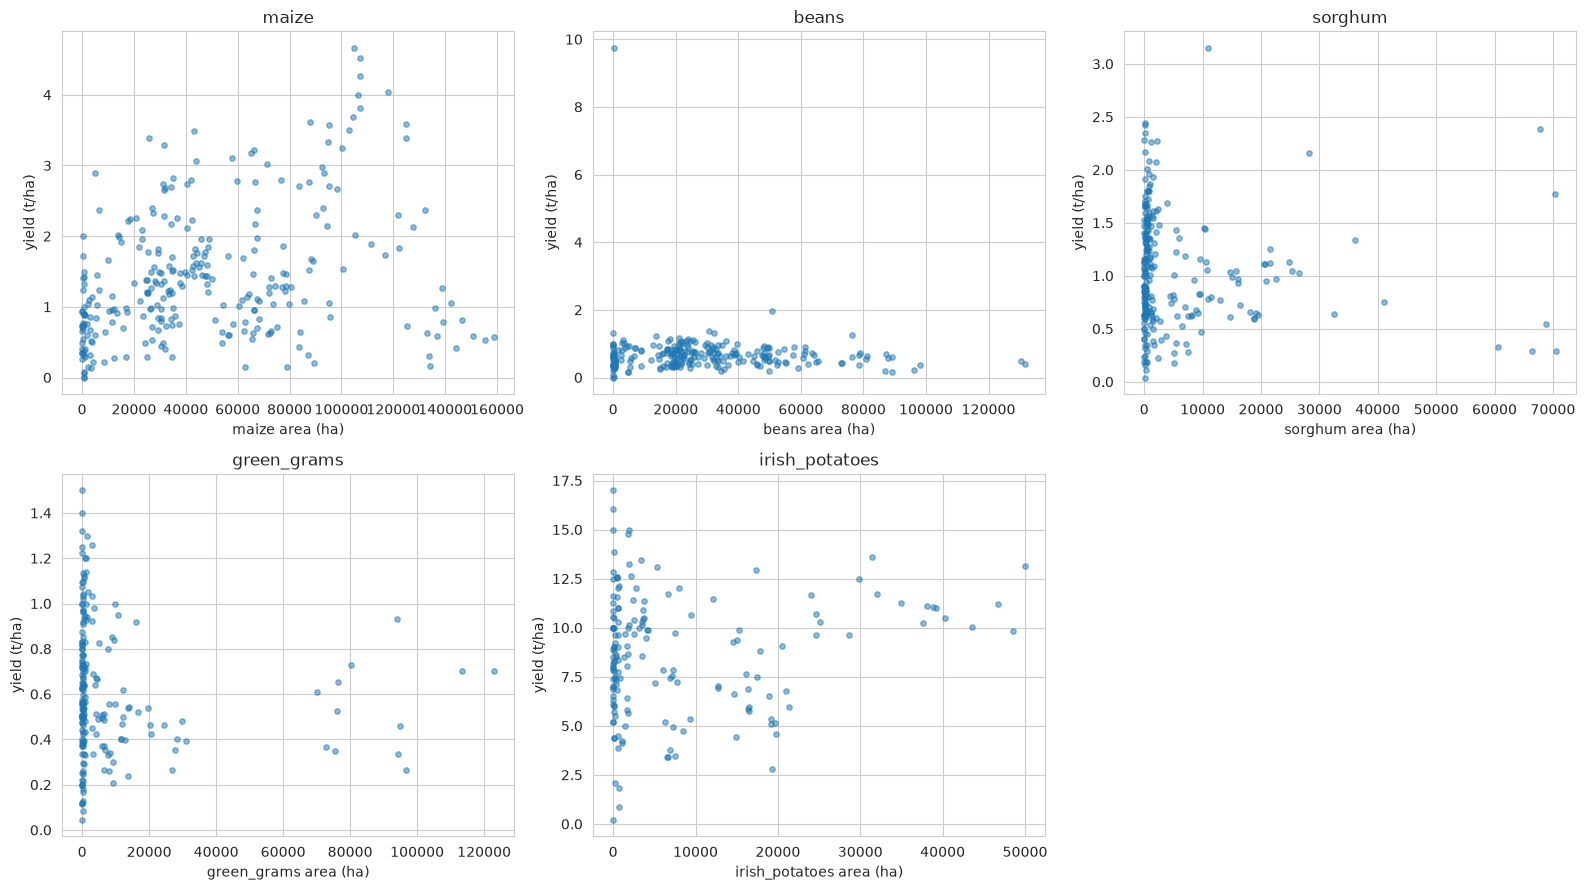

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, crop in enumerate(crops):
    axes[i].scatter(wide[f"{crop}_area_ha"], wide[f"{crop}_yield_t_per_ha"], alpha=0.5, s=15)
    axes[i].set_xlabel(f"{crop} area (ha)")
    axes[i].set_ylabel("yield (t/ha)")
    axes[i].set_title(crop)
axes[-1].axis("off")
plt.tight_layout()
plt.show()


### What this chart shows

Each panel plots **area planted (ha)** against **yield (t/ha)** for one crop, across all counties and years — this checks whether farming more land tends to produce higher or lower yield per hectare.

**Key observations:**

- **Most points cluster near the low end of area** for every crop — the vast majority of county-year entries involve relatively small planted areas, with a smaller number of counties farming much larger areas (the long tail to the right).
- **No strong linear relationship for most crops.** Beans, sorghum, and green grams show yield staying low and roughly flat regardless of area — a county farming 80,000 ha of beans isn't yielding noticeably more per hectare than one farming 5,000 ha. This suggests area alone isn't a strong yield driver for these three; other factors (soil, rainfall, farming practices) likely matter more.
- **Maize and Irish potatoes show a mild upward pattern at larger areas** — some of the highest-yield points appear among the larger-area counties, though the relationship is loose, not a clean trend. This is worth watching once county and weather features are in the model, since it could reflect better-resourced, larger-scale farming operations rather than area itself causing higher yield.
- **Irish potatoes has by far the widest yield spread at every area level** — consistent with what the earlier boxplot showed, yield swings from ~2.5 to 17.5 t/ha even among counties planting similar (small) areas, pointing to other factors (soil, altitude, drought exposure) driving the variation more than area does.

**Takeaway:** area planted looks like a weak predictor on its own for most crops — this supports the plan to bring in weather and soil data, since those are more likely to explain the yield variation area alone doesn't.


### 4.5 Which counties are missing entirely for each crop (don't grow it, not a data error)

In [19]:
for crop in crops + ["tea", "coffee"]:
    if crop == "tea":
        missing = wide[wide["tea_made_tea_kg"].isna()]["county"].unique()
    elif crop == "coffee":
        missing = wide[wide["coffee_total_area_ha"].isna()]["county"].unique()
    else:
        missing = wide[wide[f"{crop}_production_tons"] == 0]["county"].unique()
    print(f"{crop}: {len(missing)} counties with no recorded production")


maize: 3 counties with no recorded production
beans: 10 counties with no recorded production
sorghum: 10 counties with no recorded production
green_grams: 19 counties with no recorded production
irish_potatoes: 23 counties with no recorded production
tea: 34 counties with no recorded production
coffee: 49 counties with no recorded production


### 4.6 Correlation heatmap — full feature set

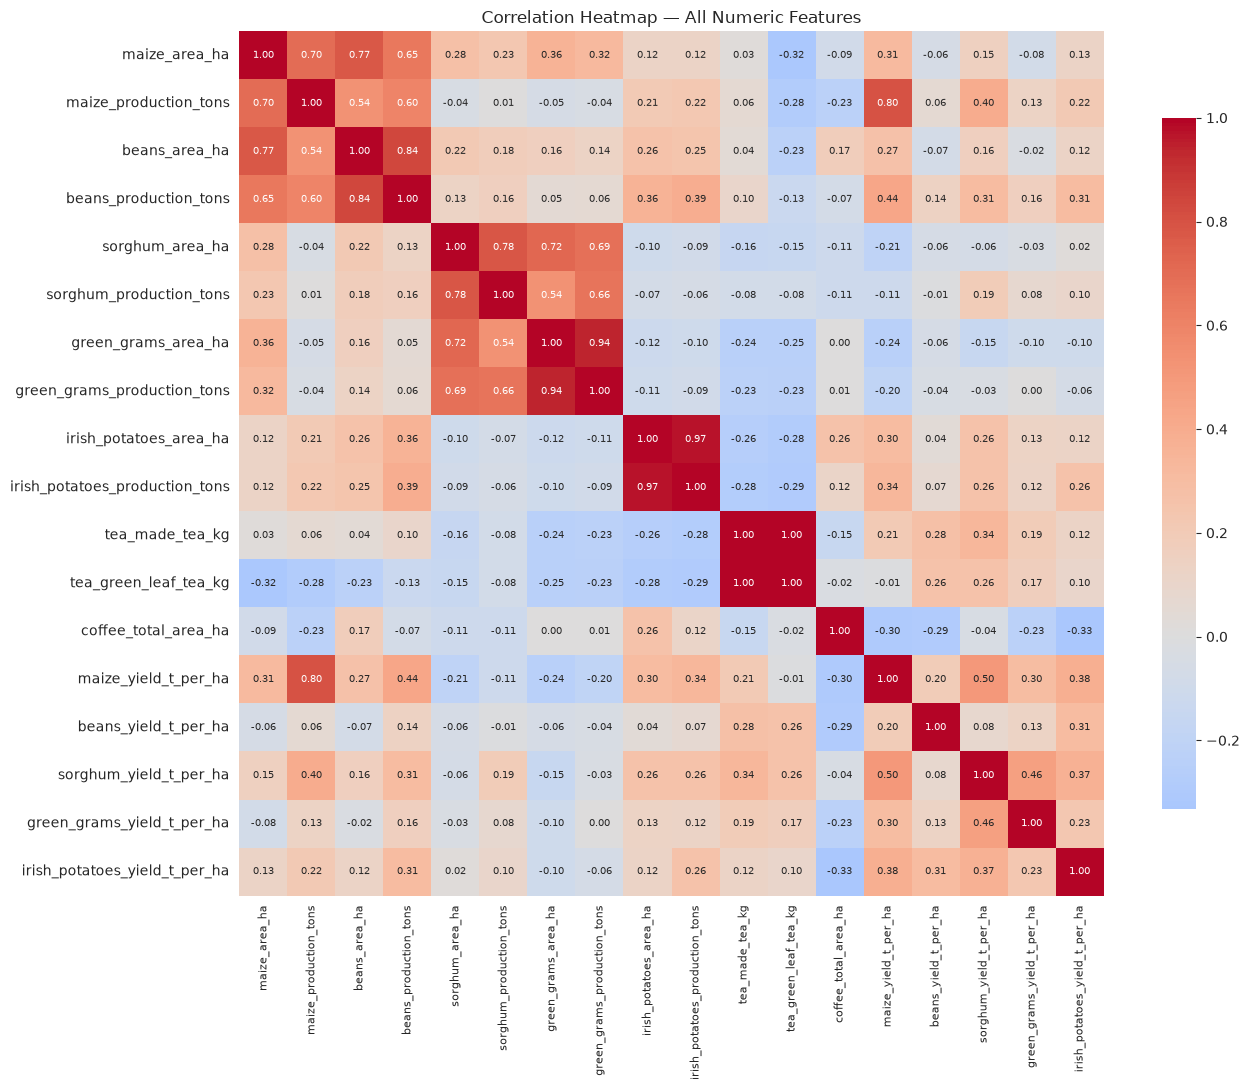

In [20]:
plt.figure(figsize=(14, 11))
numeric_cols = [c for c in wide.columns if c not in ["county", "year"]]
corr = wide[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            annot_kws={"size":7}, cbar_kws={"shrink":0.8})
plt.title("Correlation Heatmap — All Numeric Features")
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()


In [21]:
# Focusing specifically on what correlates with each crop's yield
yield_cols = [f"{c}_yield_t_per_ha" for c in crops]
for yc in yield_cols:
    print(f"\n--- {yc} ---")
    print(corr[yc].drop(yield_cols).sort_values(ascending=False).round(2))



--- maize_yield_t_per_ha ---
maize_production_tons             0.80
beans_production_tons             0.44
irish_potatoes_production_tons    0.34
maize_area_ha                     0.31
irish_potatoes_area_ha            0.30
beans_area_ha                     0.27
tea_made_tea_kg                   0.21
tea_green_leaf_tea_kg            -0.01
sorghum_production_tons          -0.11
green_grams_production_tons      -0.20
sorghum_area_ha                  -0.21
green_grams_area_ha              -0.24
coffee_total_area_ha             -0.30
Name: maize_yield_t_per_ha, dtype: float64

--- beans_yield_t_per_ha ---
tea_made_tea_kg                   0.28
tea_green_leaf_tea_kg             0.26
beans_production_tons             0.14
irish_potatoes_production_tons    0.07
maize_production_tons             0.06
irish_potatoes_area_ha            0.04
sorghum_production_tons          -0.01
green_grams_production_tons      -0.04
maize_area_ha                    -0.06
green_grams_area_ha              -0.06


### 4.7 Kenya land classification map — farmable vs. arid land

Requires a local shapefile (`ken_admin1.shp`, from HDX/OCHA) and `county_land_classification_v2.csv` — both are local files not bundled with this notebook, so this section runs on the original machine where they were downloaded.


In [22]:
kenya = gpd.read_file("DATA/ken_admin1.shp")
print(kenya.columns.tolist())


['adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3', 'adm1_pcode', 'adm0_name', 'adm0_name1', 'adm0_name2', 'adm0_name3', 'adm0_pcode', 'valid_on', 'valid_to', 'area_sqkm', 'version', 'lang', 'lang1', 'lang2', 'lang3', 'adm1_ref_n', 'center_lat', 'center_lon', 'geometry']


In [23]:
county_totals = wide.groupby("county")[[f"{c}_production_tons" for c in crops]].sum()
county_totals["total_production"] = county_totals.sum(axis=1)

lowest = county_totals.sort_values("total_production").head(10)
print(lowest[["total_production"]])


                     total_production
county                               
Kakamega/Vihiga                   0.0
Trans-Nzoia/Bungoma               0.0
Garissa                        1915.0
Isiolo                         2312.0
Wajir                          2524.0
Mombasa                        3128.0
Marsabit                       3526.0
Nairobi                        6856.0
Mandera                       17692.0
Turkana                       36296.0


In [24]:
classification_v2 = pd.read_csv("DATA/county_land_classification_v2.csv")

# standardize the shapefile's hyphenated names to match the CSV's spelling
kenya["adm1_name"] = kenya["adm1_name"].replace({
    "Elgeyo-Marakwet": "Elgeyo Marakwet",
    "Tharaka-Nithi": "Tharaka Nithi",
})

kenya = kenya.merge(classification_v2[["county", "land_classification_refined"]],
                     left_on="adm1_name", right_on="county", how="left")

print(kenya.columns.tolist())
print(kenya["land_classification_refined"].value_counts())

missing = kenya[kenya["land_classification_refined"].isna()]
print("\nCounties still missing a classification:", missing["adm1_name"].tolist())


['adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3', 'adm1_pcode', 'adm0_name', 'adm0_name1', 'adm0_name2', 'adm0_name3', 'adm0_pcode', 'valid_on', 'valid_to', 'area_sqkm', 'version', 'lang', 'lang1', 'lang2', 'lang3', 'adm1_ref_n', 'center_lat', 'center_lon', 'geometry', 'county', 'land_classification_refined']
land_classification_refined
Non-ASAL (higher agricultural potential)                  24
Semi-Arid (ASAL)                                          14
Arid (ASAL core)                                           5
Minimal/No Crop Farming (confirmed by production data)     4
Name: count, dtype: int64

Counties still missing a classification: []


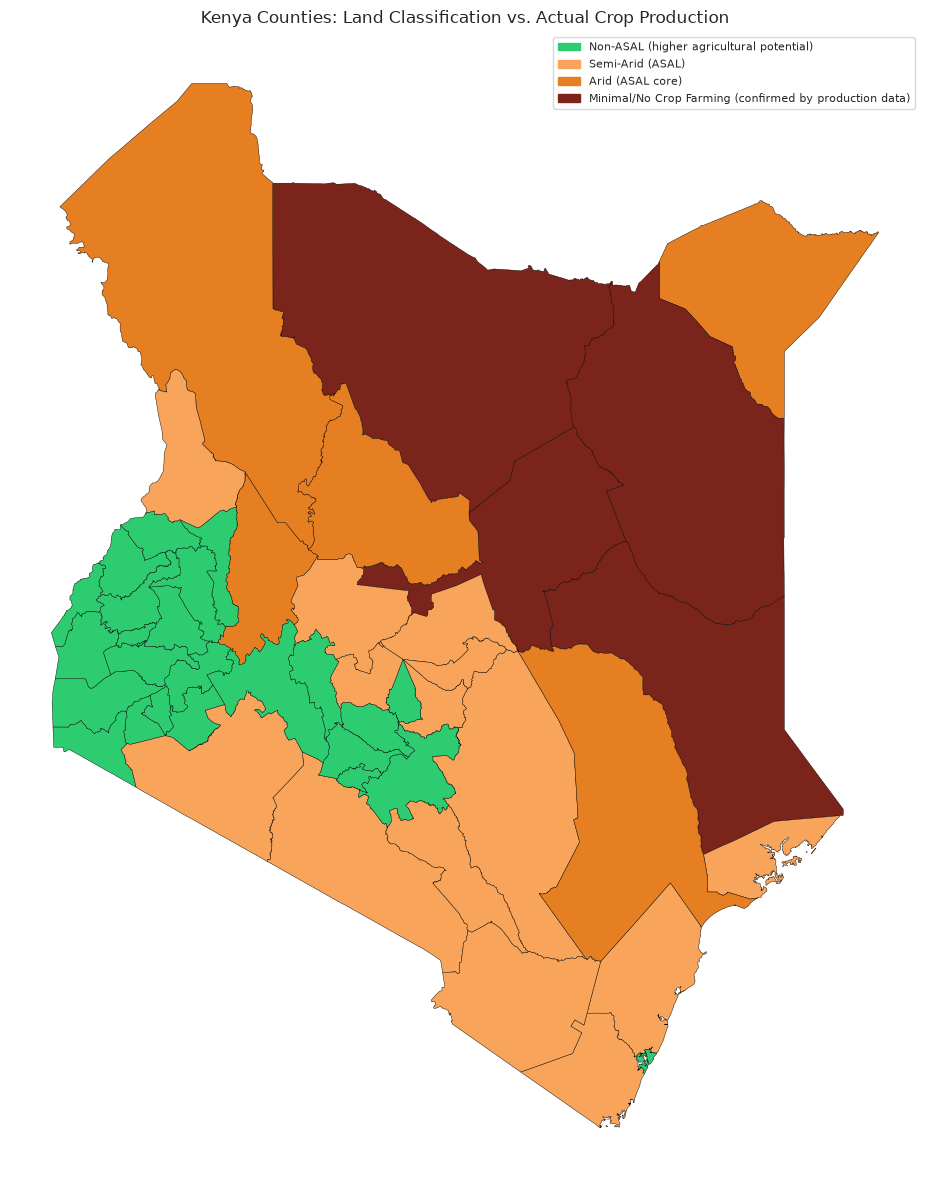

In [25]:
color_map = {
    "Non-ASAL (higher agricultural potential)": "#2ecc71",          # green — farmable
    "Semi-Arid (ASAL)": "#f8a45a",                                    # peach
    "Arid (ASAL core)": "#e67e22",                                    # orange — arid but still farms
    "Minimal/No Crop Farming (confirmed by production data)": "#7b241c",  # dark red — near-zero, evidence-based
}

fig, ax = plt.subplots(figsize=(10, 12))
kenya["color"] = kenya["land_classification_refined"].map(color_map)
kenya.plot(color=kenya["color"], ax=ax, edgecolor="black", linewidth=0.3)

import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
ax.legend(handles=legend_handles, loc="upper right", fontsize=8)

ax.set_title("Kenya Counties: Land Classification vs. Actual Crop Production")
ax.axis("off")
plt.tight_layout()
plt.show()


### 4.8 Tea — production trends

Tea only has production data (kg), not area, so no yield (t/ha) can be computed for it — shown here as production trends only.


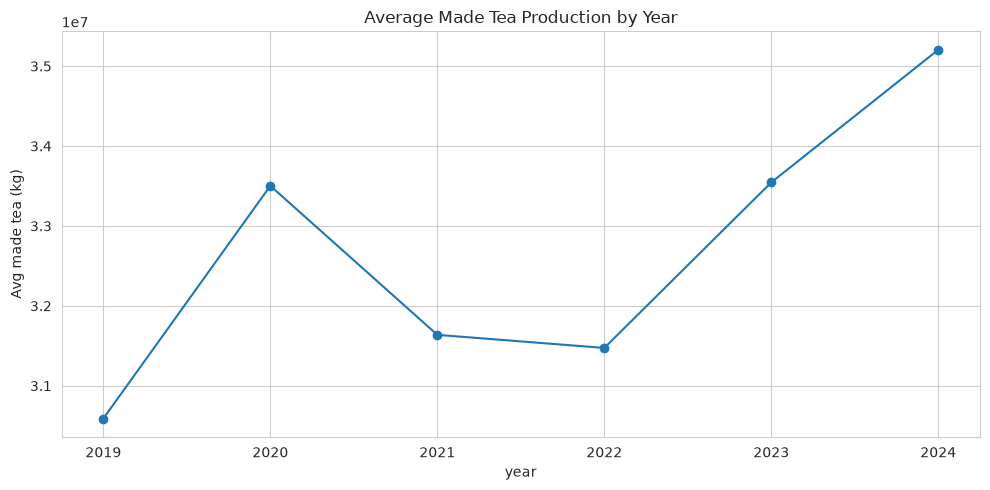

In [26]:
tea_df = wide.dropna(subset=["tea_made_tea_kg"])

plt.figure(figsize=(10, 5))
tea_df.groupby("year")["tea_made_tea_kg"].mean().plot(marker="o")
plt.ylabel("Avg made tea (kg)")
plt.title("Average Made Tea Production by Year")
plt.tight_layout()
plt.show()


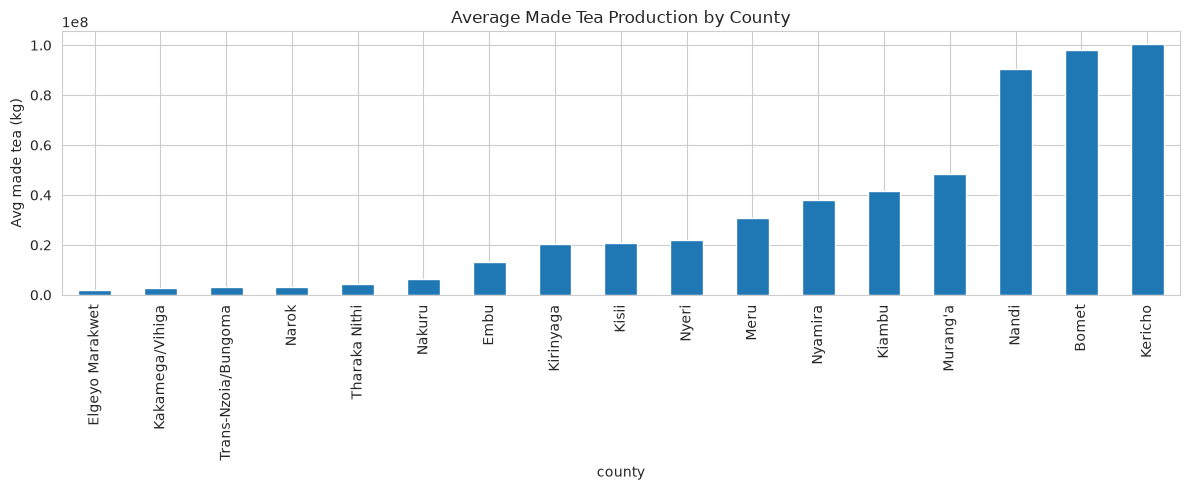

In [27]:
plt.figure(figsize=(12, 5))
tea_df.groupby("county")["tea_made_tea_kg"].mean().sort_values().plot(kind="bar")
plt.ylabel("Avg made tea (kg)")
plt.title("Average Made Tea Production by County")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### 4.9 Coffee — area trends

Coffee only has area data (ha), not production, so no yield can be computed here either — area under cultivation only, and only 3 crop-years exist (2022–2024).


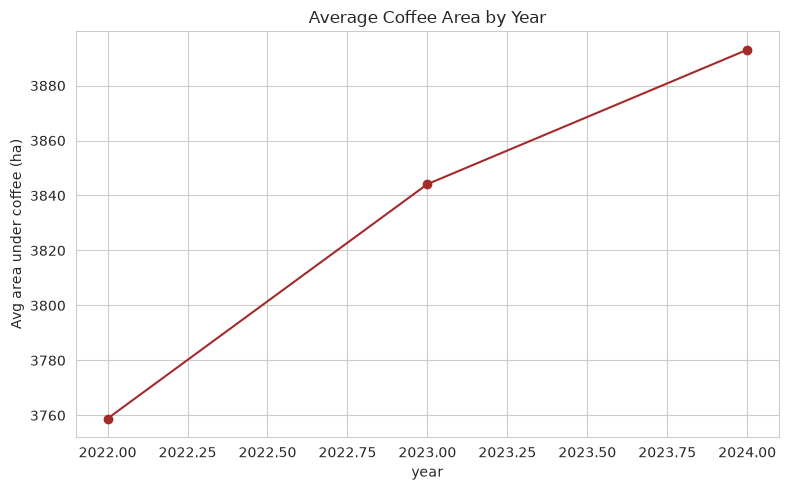

In [28]:
coffee_df = wide.dropna(subset=["coffee_total_area_ha"])

plt.figure(figsize=(8, 5))
coffee_df.groupby("year")["coffee_total_area_ha"].mean().plot(marker="o", color="brown")
plt.ylabel("Avg area under coffee (ha)")
plt.title("Average Coffee Area by Year")
plt.tight_layout()
plt.show()


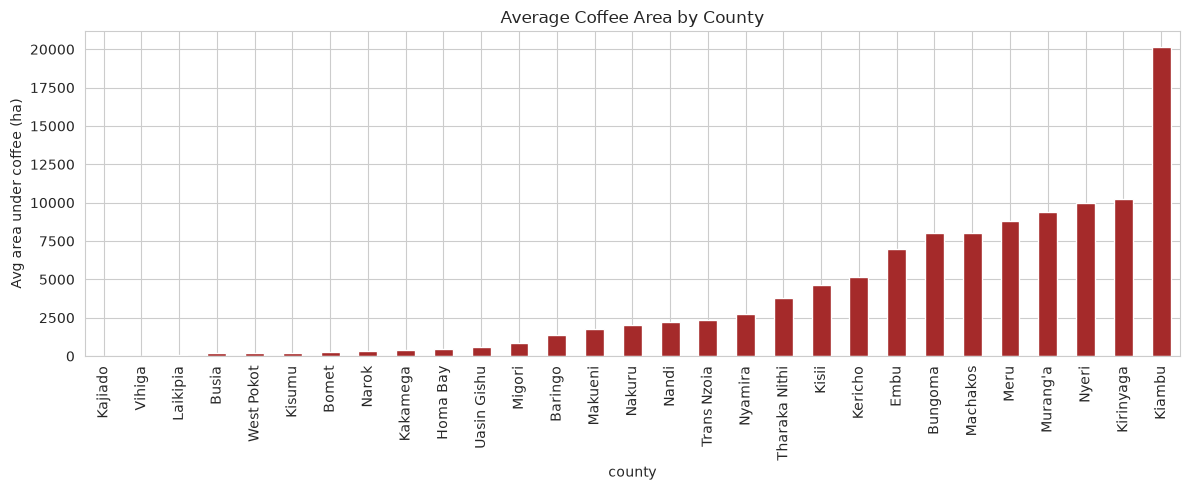

In [29]:
plt.figure(figsize=(12, 5))
coffee_df.groupby("county")["coffee_total_area_ha"].mean().sort_values().plot(kind="bar", color="brown")
plt.ylabel("Avg area under coffee (ha)")
plt.title("Average Coffee Area by County")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### 4.10 Does farm size predict yield?

We group counties into 5 equal-sized bins by area planted and compare average yield per bin, to test more rigorously whether farm size actually predicts yield — the earlier scatter plots suggested it mostly doesn't.


In [30]:
for crop in crops:
    print(f"\n{'='*60}\n{crop.upper()}\n{'='*60}")
    df = wide[(wide[f"{crop}_area_ha"] > 0) & (wide[f"{crop}_yield_t_per_ha"].notna())].copy()

    # Smallest area on record that still produced a valid yield
    min_row = df.loc[df[f"{crop}_area_ha"].idxmin()]
    print(f"Smallest area on record: {min_row[f'{crop}_area_ha']:.0f} ha "
          f"({min_row['county']}, {int(min_row['year'])}) -> yield {min_row[f'{crop}_yield_t_per_ha']:.2f} t/ha")

    # Bin into quintiles by area, compare mean yield per bin
    df["area_bin"] = pd.qcut(df[f"{crop}_area_ha"], q=5, duplicates="drop")
    bin_stats = df.groupby("area_bin", observed=True)[f"{crop}_yield_t_per_ha"].agg(["mean", "count"])
    print("\nMean yield by area range (quintiles):")
    print(bin_stats.round(2))

    best_bin = bin_stats["mean"].idxmax()
    print(f"\n-> Highest average yield occurs in area range: {best_bin} "
          f"(mean {bin_stats['mean'].max():.2f} t/ha)")



MAIZE
Smallest area on record: 54 ha (Wajir, 2021) -> yield 0.35 t/ha

Mean yield by area range (quintiles):
                     mean  count
area_bin                        
(53.999, 9146.0]     0.80     57
(9146.0, 30849.0]    1.31     56
(30849.0, 48352.0]   1.68     56
(48352.0, 79493.4]   1.35     56
(79493.4, 158761.0]  2.00     57

-> Highest average yield occurs in area range: (79493.4, 158761.0] (mean 2.00 t/ha)

BEANS
Smallest area on record: 3 ha (Kilifi, 2024) -> yield 0.33 t/ha

Mean yield by area range (quintiles):
                     mean  count
area_bin                        
(2.999, 3837.0]      0.73     51
(3837.0, 19943.0]    0.62     50
(19943.0, 29922.0]   0.74     50
(29922.0, 48121.0]   0.67     50
(48121.0, 131624.0]  0.61     50

-> Highest average yield occurs in area range: (19943.0, 29922.0] (mean 0.74 t/ha)

SORGHUM
Smallest area on record: 2 ha (Kajiado, 2023) -> yield 1.00 t/ha

Mean yield by area range (quintiles):
                   mean  count
area_

## 5. Feature Engineering — Weather and Soil

Two more feature sources are needed before modeling: **rainfall/temperature** (NASA POWER API) and **soil characteristics** (iSDAsoil API), both queried by county centroid coordinates.

> **Note:** the cells in this section need internet access and (for soil) a free iSDAsoil API key, plus files only present on the original machine (`county_centroids.csv`, downloaded shapefile). They are shown here as-written and verified, but are not executed in this copy of the notebook.


### 5.1 Get county centroid coordinates

In [31]:
import geopy
print(geopy.__version__)


2.5.0


In [34]:
try:
    from geopy.geocoders import Nominatim
    import time

    geolocator = Nominatim(user_agent="agripredict")
    rows = []
    for county in sorted(wide["county"].unique()):
        query = f"{county.split('/')[0]} County, Kenya"
        location = geolocator.geocode(query)
        if location:
            rows.append([county, location.latitude, location.longitude])
        else:
            print("not found:", county)
        time.sleep(1)  # Nominatim rate limit: 1 request/sec

    centroids = pd.DataFrame(rows, columns=["county", "lat", "lon"])
    centroids.to_csv("DATA/county_centroids.csv", index=False)
    print(centroids.shape)
except Exception as e:
    print("Geocoding skipped (no internet access in this environment):", e)
    if os.path.exists("DATA/county_centroids.csv"):
        centroids = pd.read_csv("DATA/county_centroids.csv")
        print("Loaded previously saved centroids instead:", centroids.shape)
    else:
        centroids = None


(49, 3)


### 5.2 Pull annual weather (rainfall, temperature) per county from NASA POWER

In [33]:
import requests

def get_weather(lat, lon, start, end):
    url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    params = {
        "parameters": "T2M,T2M_MAX,T2M_MIN,PRECTOTCORR",
        "community": "AG",
        "longitude": lon,
        "latitude": lat,
        "start": start,
        "end": end,
        "format": "JSON",
    }
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    return r.json()

def daily_to_annual(data, year):
    precip = data["properties"]["parameter"]["PRECTOTCORR"]
    temp = data["properties"]["parameter"]["T2M"]
    total_rain = sum(v for v in precip.values() if v != -999)
    avg_temp = sum(v for v in temp.values() if v != -999) / len(temp)
    return {"year": year, "rainfall_mm": total_rain, "avg_temp_c": avg_temp}

weather_rows = []
if centroids is not None:
    try:
        for _, row in centroids.iterrows():
            for year in [2019, 2020, 2021, 2022, 2023, 2024]:
                data = get_weather(row["lat"], row["lon"], f"{year}0101", f"{year}1231")
                stats = daily_to_annual(data, year)
                stats["county"] = row["county"]
                weather_rows.append(stats)
        weather = pd.DataFrame(weather_rows)
        weather.to_csv("DATA/weather_annual.csv", index=False)
        print(weather.shape)
    except Exception as e:
        print("NASA POWER fetch skipped (no internet access in this environment):", e)
        weather = pd.read_csv("DATA/weather_annual.csv") if os.path.exists("DATA/weather_annual.csv") else None
else:
    weather = pd.read_csv("DATA/weather_annual.csv") if os.path.exists("DATA/weather_annual.csv") else None


(294, 4)


### 5.3 Pull static soil properties per county from iSDAsoil (requires a free API key)

In [35]:
import requests

# --- Config ---
ISDA_USERNAME = "marlicchege@gmail.com"
ISDA_PASSWORD = "Marlic"

# --- Helper functions ---
def get_isda_token(username, password):
    url = "https://api.isda-africa.com/login"
    data = {"username": username, "password": password}
    r = requests.post(url, data=data, timeout=30)
    r.raise_for_status()
    return r.json()["access_token"]

def get_soil(lat, lon, token):
    url = "https://api.isda-africa.com/isdasoil/v2/soilproperty"
    headers = {"Authorization": f"Bearer {token}"}
    params = {"lat": lat, "lon": lon}
    r = requests.get(url, params=params, headers=headers, timeout=30)
    r.raise_for_status()
    return r.json()

# --- Manual coordinate override: iSDAsoil rejects points over water/deserts.
# Kisumu's geocoded centroid landed on Lake Victoria — corrected to Kisumu town itself. ---
COORD_OVERRIDES = {
    "Kisumu": (-0.0917, 34.7680),
}

# --- Fetch soil pH per county ---
soil_rows = []
failed_counties = []

if centroids is not None:
    token = get_isda_token(ISDA_USERNAME, ISDA_PASSWORD)
    for _, row in centroids.iterrows():
        county = row["county"]
        lat, lon = COORD_OVERRIDES.get(county, (row["lat"], row["lon"]))
        try:
            soil_data = get_soil(lat, lon, token)
            ph = soil_data["property"]["ph"][0]["value"]["value"]
            soil_rows.append({"county": county, "soil_ph": ph})
        except Exception as e:
            print(f"Skipped {county}: {e}")
            failed_counties.append(county)

    soil = pd.DataFrame(soil_rows)
    soil.to_csv("DATA/soil.csv", index=False)
    print(f"\nSucceeded: {len(soil_rows)} / {len(centroids)} counties")
    if failed_counties:
        print(f"Failed: {failed_counties}")
else:
    print("iSDAsoil skipped: no centroids available.")
    soil = pd.read_csv("DATA/soil.csv") if os.path.exists("DATA/soil.csv") else None



Succeeded: 49 / 49 counties


### 5.4 Merge weather and soil into the wide table, where available

In [36]:
if weather is not None:
    wide = wide.merge(weather, on=["county", "year"], how="left")
    print("Weather merged.")
else:
    print("Weather not available — modeling below proceeds with crop-only features.")

if soil is not None:
    wide = wide.merge(soil, on="county", how="left")
    print("Soil merged.")
else:
    print("Soil not available — modeling below proceeds without it.")

wide.to_csv("DATA/agripredict_wide.csv", index=False)
wide.shape


Weather merged.
Soil merged.


(294, 23)

### Check if the merge worked

In [37]:
print(wide.shape)
print(wide[["rainfall_mm", "avg_temp_c", "soil_ph"]].describe())
print(wide[["rainfall_mm", "avg_temp_c", "soil_ph"]].isna().mean() * 100)


(294, 23)
       rainfall_mm  avg_temp_c     soil_ph
count   294.000000  294.000000  294.000000
mean   1522.619694   21.359801    6.269388
std     871.180561    3.673968    0.679149
min     144.290000   15.371421    5.300000
25%     747.715000   18.731384    5.700000
50%    1389.810000   20.355799    6.100000
75%    2063.737500   23.805582    6.600000
max    3457.720000   29.639589    8.000000
rainfall_mm    0.0
avg_temp_c     0.0
soil_ph        0.0
dtype: float64


### 5.5 Correlation — yield vs. weather and soil

In [38]:
numeric_cols = [c for c in wide.columns if c not in ["county", "year"]]
corr = wide[numeric_cols].corr()

for yc in [f"{c}_yield_t_per_ha" for c in crops]:
    print(f"\n--- {yc} ---")
    print(corr[yc][["rainfall_mm", "avg_temp_c", "soil_ph"]].round(2))



--- maize_yield_t_per_ha ---
rainfall_mm    0.57
avg_temp_c    -0.44
soil_ph       -0.44
Name: maize_yield_t_per_ha, dtype: float64

--- beans_yield_t_per_ha ---
rainfall_mm    0.08
avg_temp_c    -0.02
soil_ph       -0.07
Name: beans_yield_t_per_ha, dtype: float64

--- sorghum_yield_t_per_ha ---
rainfall_mm    0.36
avg_temp_c    -0.23
soil_ph       -0.22
Name: sorghum_yield_t_per_ha, dtype: float64

--- green_grams_yield_t_per_ha ---
rainfall_mm    0.10
avg_temp_c    -0.01
soil_ph        0.12
Name: green_grams_yield_t_per_ha, dtype: float64

--- irish_potatoes_yield_t_per_ha ---
rainfall_mm    0.42
avg_temp_c    -0.15
soil_ph       -0.20
Name: irish_potatoes_yield_t_per_ha, dtype: float64


### 5.6 Full correlation heatmap (with weather & soil)

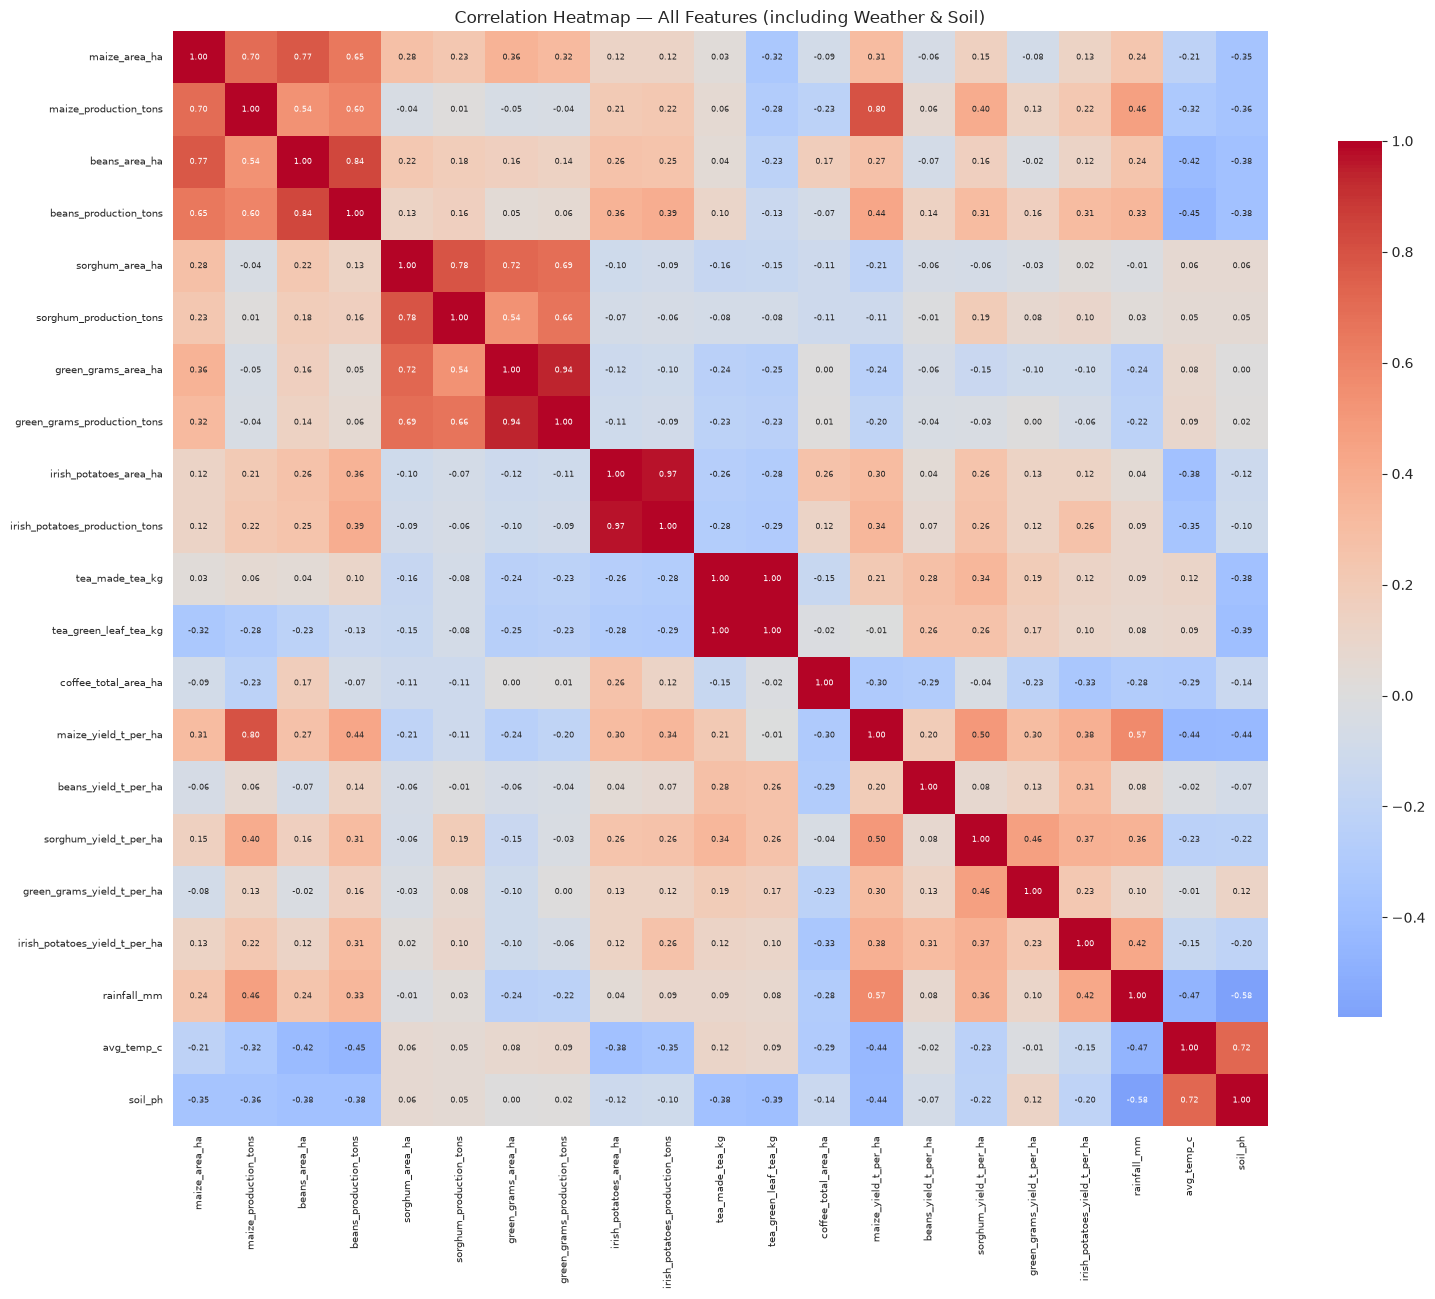

In [39]:
numeric_cols = [c for c in wide.columns if c not in ["county", "year"]]
corr = wide[numeric_cols].corr()

plt.figure(figsize=(16, 13))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            annot_kws={"size": 6}, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap — All Features (including Weather & Soil)")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()


## 6. Modeling

- Train/validation/test split, Linear Regression, Random Forest, XGBoost, and full model comparison, for all crops from the start.


In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import joblib

os.makedirs("models", exist_ok=True)

## 6. Modeling — Linear Regression 

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import joblib, os

os.makedirs("models", exist_ok=True)
crops = ["maize", "beans", "sorghum", "green_grams", "irish_potatoes"]

### 6.1 Build features and split, per crop

In [45]:
def prepare_crop_data(crop, verbose=True):
    model_df = wide[wide[f"{crop}_yield_t_per_ha"].notna()].copy()
    model_df = pd.get_dummies(model_df, columns=["county"], drop_first=True)

    county_cols = [c for c in model_df.columns if c.startswith("county_")]
    model_df[county_cols] = model_df[county_cols].astype(int)

    feature_cols = county_cols + [f"{crop}_area_ha", "rainfall_mm", "avg_temp_c", "soil_ph"]

    X = model_df[feature_cols].fillna(0)
    y = model_df[f"{crop}_yield_t_per_ha"]
    years = model_df["year"]

    train_mask, val_mask, test_mask = years <= 2022, years == 2023, years == 2024
    X_train, y_train = X[train_mask].reset_index(drop=True), y[train_mask].reset_index(drop=True)
    X_val, y_val = X[val_mask].reset_index(drop=True), y[val_mask].reset_index(drop=True)
    X_test, y_test = X[test_mask].reset_index(drop=True), y[test_mask].reset_index(drop=True)

    if verbose:
        print(f"{crop}: train={len(X_train)} val={len(X_val)} test={len(X_test)}")

    return X_train, y_train, X_val, y_val, X_test, y_test

def full_report(y_true, y_pred, label, n_features):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1) if n > n_features + 1 else float("nan")
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"{label:20s} MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.3f}  AdjR2={adj_r2:.3f}  MAPE={mape:.1f}%")
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2, "Adj_R2": adj_r2, "MAPE": mape}

### 6.2 Train Linear Regression — all crops

Features are scaled (StandardScaler) since rainfall and soil pH sit on very different numeric ranges — Linear Regression is sensitive to this, unlike the tree-based models we'll use later.

In [46]:
lr_metrics = {}
lr_models = {}

for crop in crops:
    print(f"\n{'='*60}\n{crop.upper()}\n{'='*60}")
    X_train, y_train, X_val, y_val, X_test, y_test = prepare_crop_data(crop)
    n_features = X_train.shape[1]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    lr = LinearRegression().fit(X_train_scaled, y_train)
    preds_val = lr.predict(X_val_scaled)
    m = full_report(y_val, preds_val, "Linear Regression", n_features)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv = cross_val_score(LinearRegression(), X_train_scaled, y_train, cv=kf, scoring="r2")
    print(f"   5-fold CV R² (train): {cv.mean():.3f} ± {cv.std():.3f}")

    lr_metrics[crop] = m
    lr_models[crop] = {"model": lr, "scaler": scaler, "X_val": X_val_scaled, "y_val": y_val}
    joblib.dump({"model": lr, "scaler": scaler}, f"models/{crop}_lr.joblib")


MAIZE
maize: train=188 val=47 test=47
Linear Regression    MAE=0.334  RMSE=0.446  R2=0.728  AdjR2=nan  MAPE=24.4%
   5-fold CV R² (train): 0.736 ± 0.078

BEANS
beans: train=165 val=43 test=43
Linear Regression    MAE=0.284  RMSE=0.460  R2=-1.042  AdjR2=nan  MAPE=40.5%
   5-fold CV R² (train): -17.254 ± 33.951

SORGHUM
sorghum: train=163 val=41 test=41
Linear Regression    MAE=0.394  RMSE=0.558  R2=0.070  AdjR2=nan  MAPE=43.8%
   5-fold CV R² (train): -0.081 ± 0.263

GREEN_GRAMS
green_grams: train=129 val=35 test=35
Linear Regression    MAE=0.164  RMSE=0.236  R2=-0.074  AdjR2=nan  MAPE=26.5%
   5-fold CV R² (train): 0.214 ± 0.204

IRISH_POTATOES
irish_potatoes: train=110 val=28 test=28
Linear Regression    MAE=1.562  RMSE=2.028  R2=0.389  AdjR2=nan  MAPE=22.3%
   5-fold CV R² (train): -0.410 ± 0.721


### 6.3 Linear Regression diagnostics — Predicted vs Actual, and Residuals, every crop

Points near the diagonal in the left column are accurate; a curved pattern in the right column (rather than random scatter around 0) would mean the relationship is too complex for a straight line to capture.

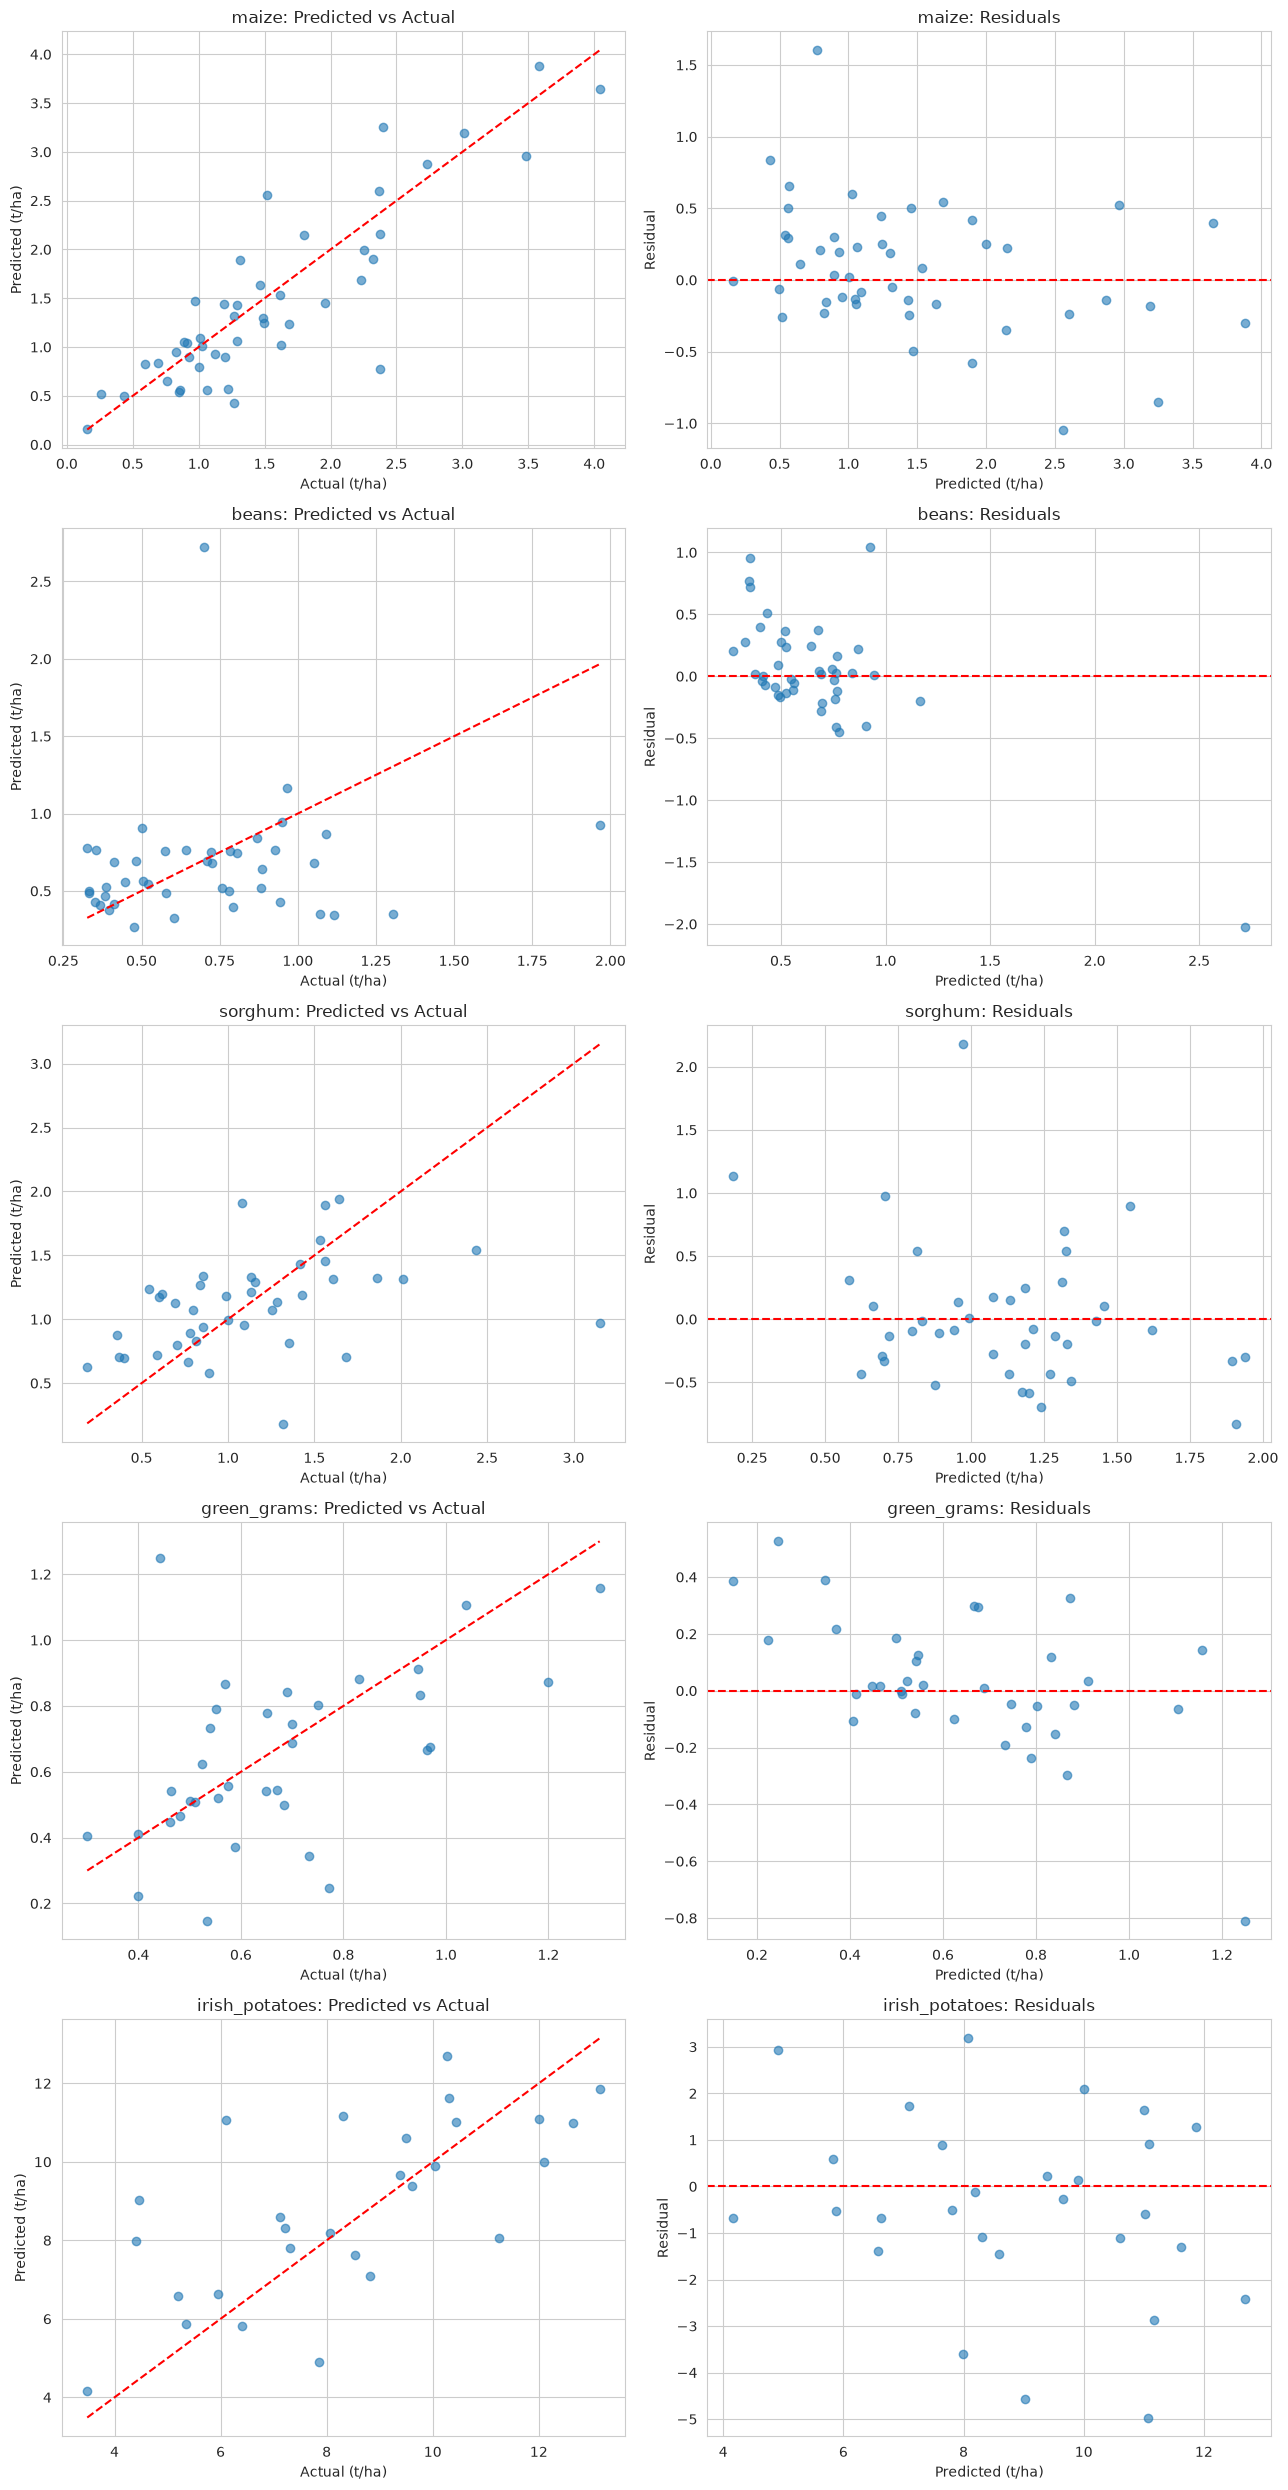

In [47]:
fig, axes = plt.subplots(len(crops), 2, figsize=(13, 5 * len(crops)))

for i, crop in enumerate(crops):
    model_info = lr_models[crop]
    preds = model_info["model"].predict(model_info["X_val"])
    y_val = model_info["y_val"]

    axes[i, 0].scatter(y_val, preds, alpha=0.6)
    axes[i, 0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
    axes[i, 0].set_title(f"{crop}: Predicted vs Actual")
    axes[i, 0].set_xlabel("Actual (t/ha)"); axes[i, 0].set_ylabel("Predicted (t/ha)")

    residuals = y_val - preds
    axes[i, 1].scatter(preds, residuals, alpha=0.6)
    axes[i, 1].axhline(0, color="r", linestyle="--")
    axes[i, 1].set_title(f"{crop}: Residuals")
    axes[i, 1].set_xlabel("Predicted (t/ha)"); axes[i, 1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

### 6.4 Linear Regression — summary table, all crops

In [48]:
pd.DataFrame(lr_metrics).T

,MAE,MSE,RMSE,R2,Adj_R2,MAPE
maize,0.333981,0.198646,0.445698,0.728272,NaN,24.389036
beans,0.283556,0.211876,0.460300,-1.041919,NaN,40.530470
sorghum,0.394456,0.310835,0.557526,0.069762,NaN,43.812846
green_grams,0.164366,0.055672,0.235950,-0.074257,NaN,26.498798
irish_potatoes,1.561987,4.110790,2.027508,0.388718,NaN,22.278645


## 7. Random Forest

In [49]:
from sklearn.ensemble import RandomForestRegressor

### 7.1 Train Random Forest — all crops

Unscaled features are used here — tree-based models split on thresholds, not distances, so feature scale doesn't affect them the way it does Linear Regression.

In [50]:
rf_metrics = {}
rf_models = {}

for crop in crops:
    print(f"\n{'='*60}\n{crop.upper()}\n{'='*60}")
    X_train, y_train, X_val, y_val, X_test, y_test = prepare_crop_data(crop)
    n_features = X_train.shape[1]

    rf = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42).fit(X_train, y_train)
    preds_val = rf.predict(X_val)
    m = full_report(y_val, preds_val, "Random Forest", n_features)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv = cross_val_score(RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42),
                          X_train, y_train, cv=kf, scoring="r2")
    print(f"   5-fold CV R² (train): {cv.mean():.3f} ± {cv.std():.3f}")

    rf_metrics[crop] = m
    rf_models[crop] = {"model": rf, "X_val": X_val, "y_val": y_val}
    joblib.dump(rf, f"models/{crop}_rf.joblib")


MAIZE
maize: train=188 val=47 test=47
Random Forest        MAE=0.399  RMSE=0.553  R2=0.581  AdjR2=nan  MAPE=32.8%
   5-fold CV R² (train): 0.616 ± 0.044

BEANS
beans: train=165 val=43 test=43
Random Forest        MAE=0.265  RMSE=0.391  R2=-0.474  AdjR2=nan  MAPE=39.1%
   5-fold CV R² (train): -5.991 ± 11.762

SORGHUM
sorghum: train=163 val=41 test=41
Random Forest        MAE=0.388  RMSE=0.562  R2=0.054  AdjR2=nan  MAPE=48.0%
   5-fold CV R² (train): 0.066 ± 0.177

GREEN_GRAMS
green_grams: train=129 val=35 test=35
Random Forest        MAE=0.165  RMSE=0.224  R2=0.031  AdjR2=nan  MAPE=23.3%
   5-fold CV R² (train): 0.193 ± 0.160

IRISH_POTATOES
irish_potatoes: train=110 val=28 test=28
Random Forest        MAE=1.863  RMSE=2.451  R2=0.107  AdjR2=nan  MAPE=28.6%
   5-fold CV R² (train): 0.124 ± 0.156


### 7.2 Random Forest diagnostics — Predicted vs Actual, and Residuals, every crop

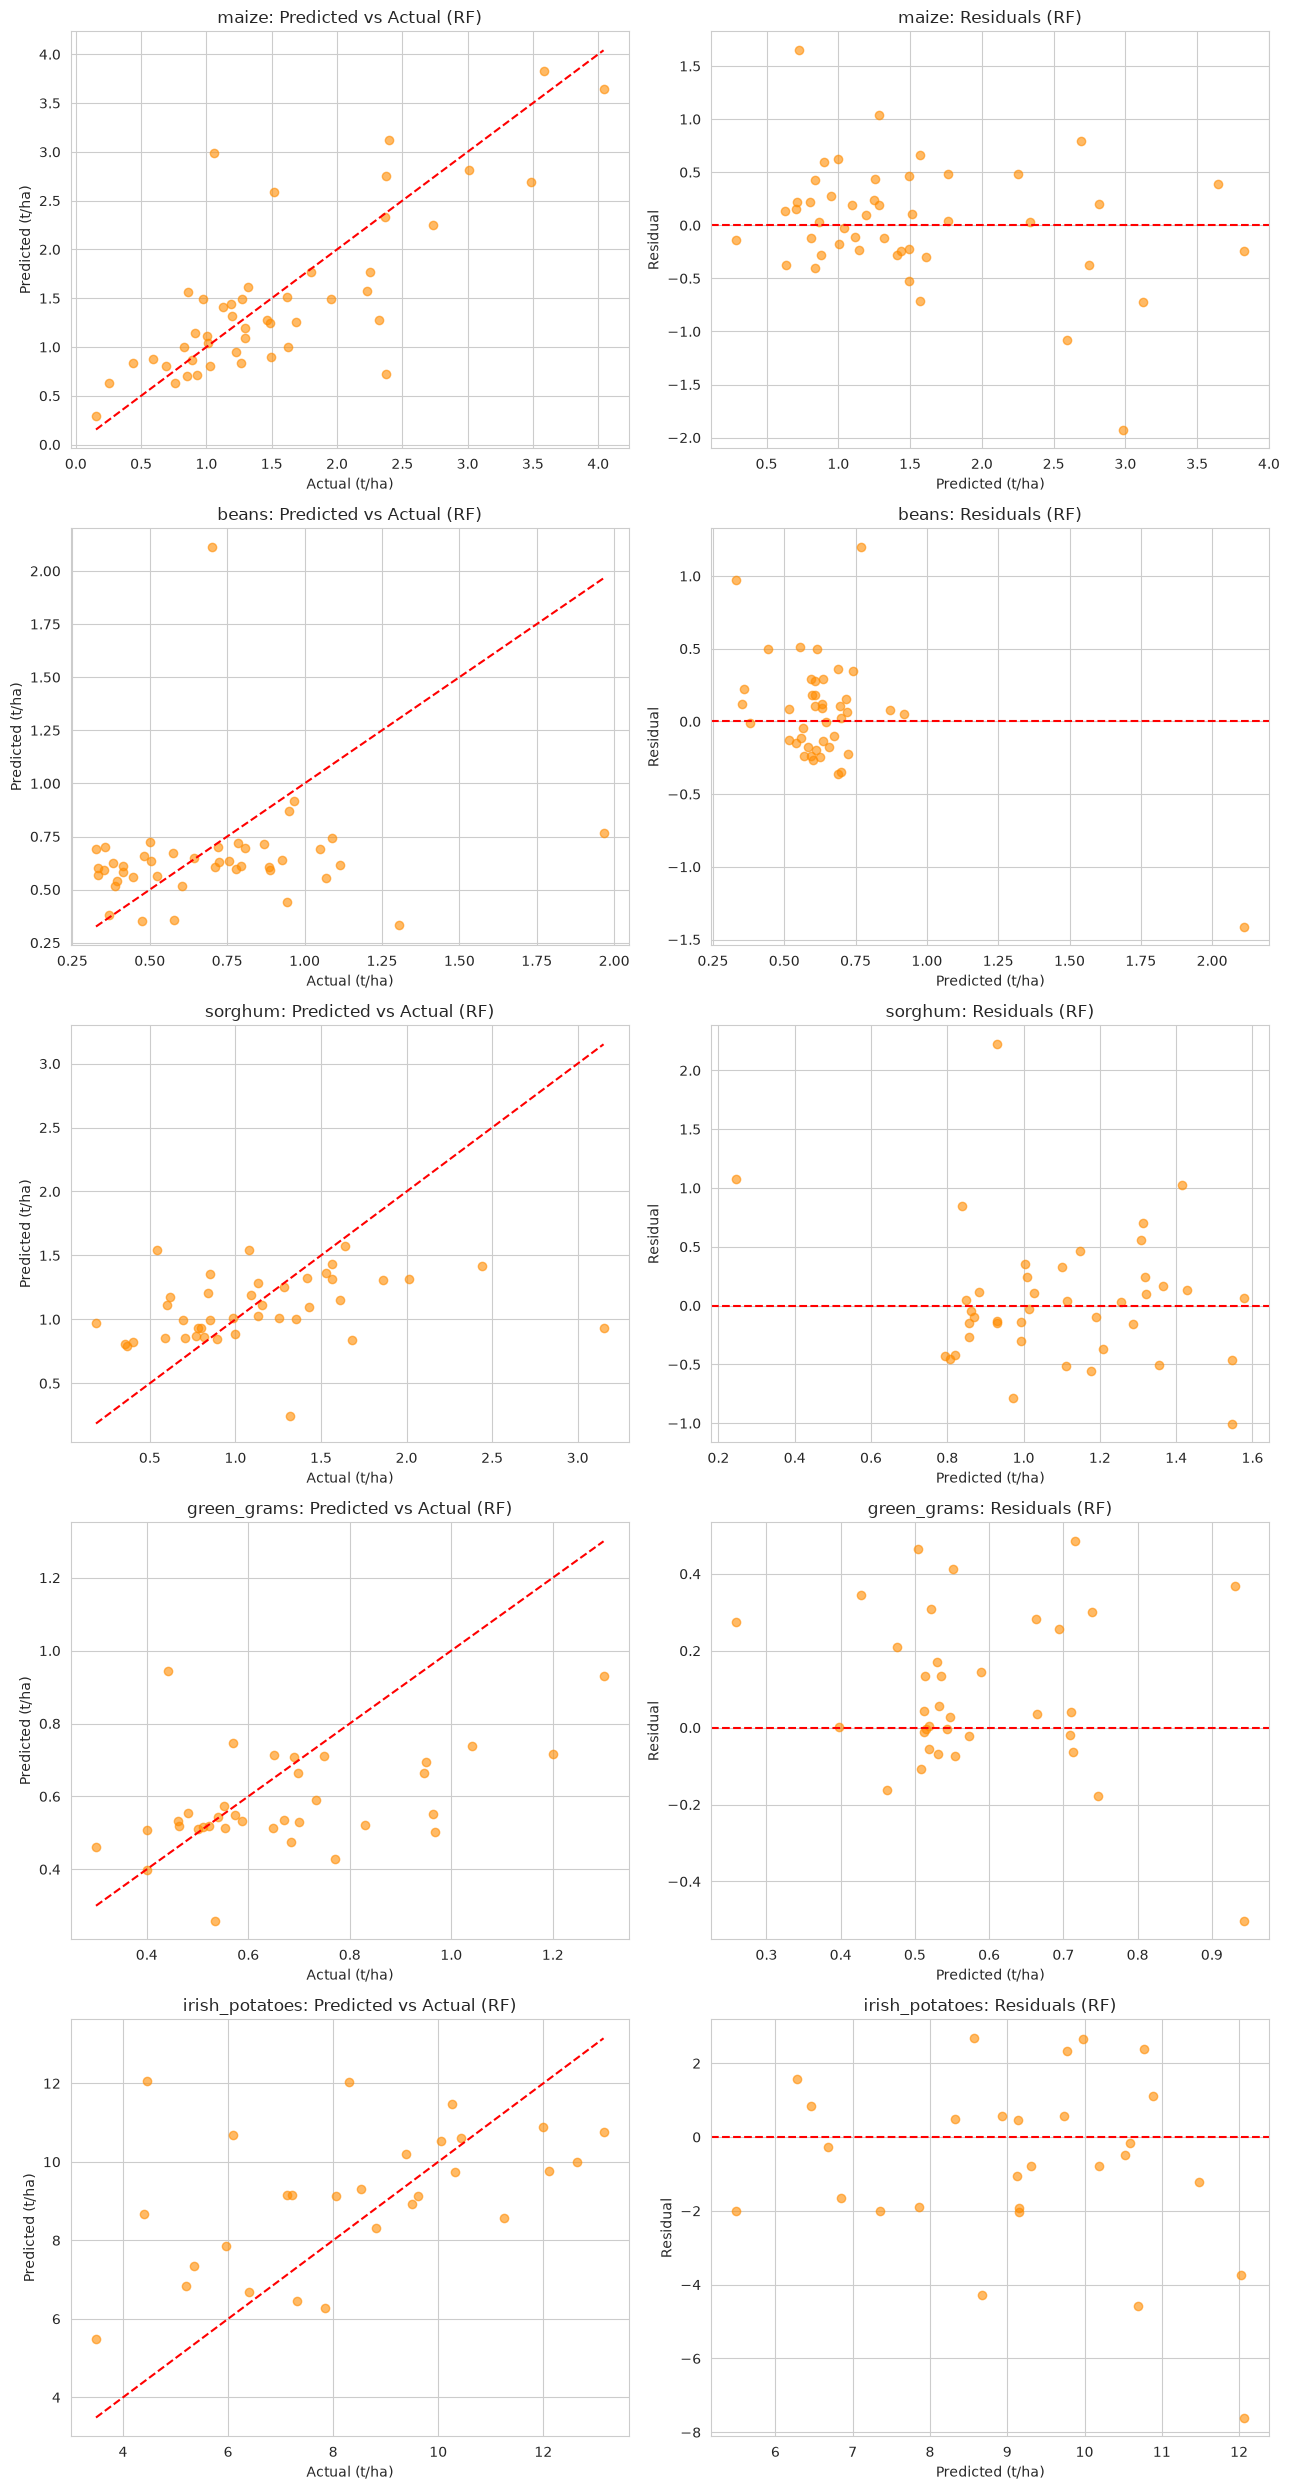

In [51]:
fig, axes = plt.subplots(len(crops), 2, figsize=(13, 5 * len(crops)))

for i, crop in enumerate(crops):
    model_info = rf_models[crop]
    preds = model_info["model"].predict(model_info["X_val"])
    y_val = model_info["y_val"]

    axes[i, 0].scatter(y_val, preds, alpha=0.6, color="darkorange")
    axes[i, 0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
    axes[i, 0].set_title(f"{crop}: Predicted vs Actual (RF)")
    axes[i, 0].set_xlabel("Actual (t/ha)"); axes[i, 0].set_ylabel("Predicted (t/ha)")

    residuals = y_val - preds
    axes[i, 1].scatter(preds, residuals, alpha=0.6, color="darkorange")
    axes[i, 1].axhline(0, color="r", linestyle="--")
    axes[i, 1].set_title(f"{crop}: Residuals (RF)")
    axes[i, 1].set_xlabel("Predicted (t/ha)"); axes[i, 1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

### 7.3 Error vs. number of trees — does adding more trees keep helping?

Random Forest has no loss-based convergence curve, but this shows the equivalent diagnostic: whether validation error keeps improving as trees are added, or has already flattened out at 300.

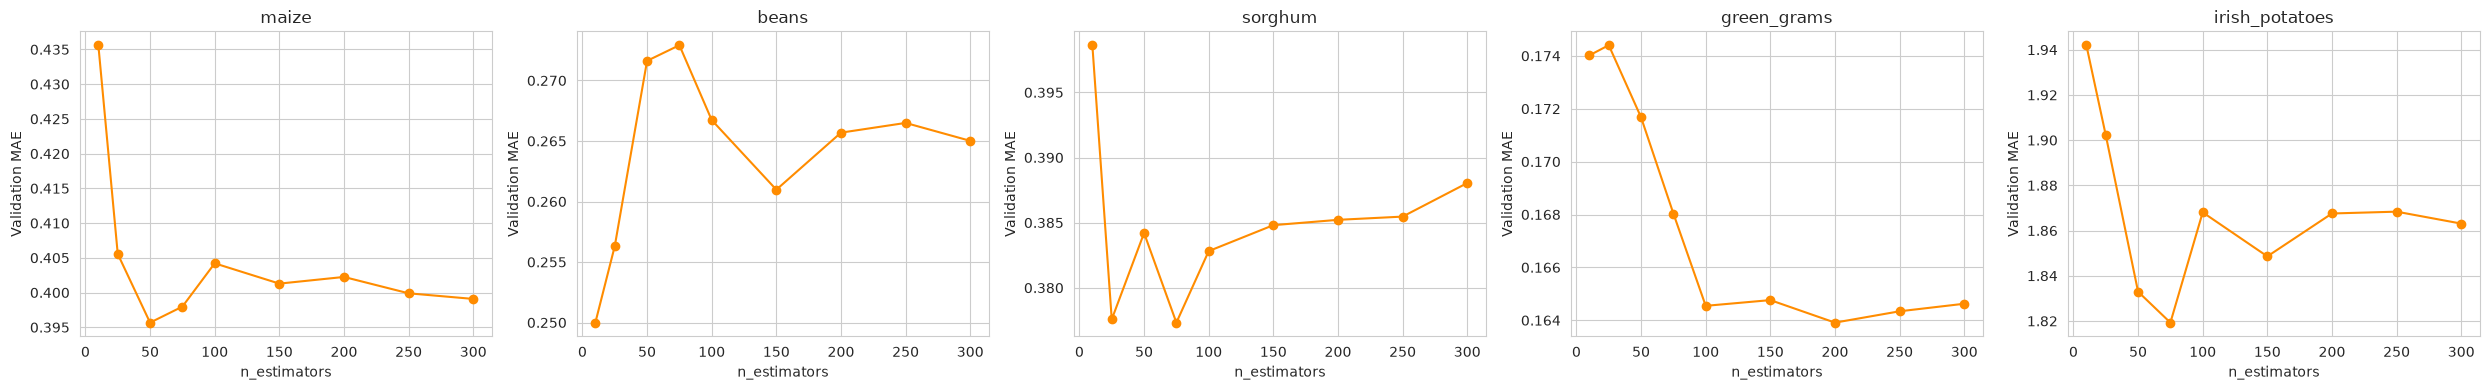

In [52]:
tree_counts = [10, 25, 50, 75, 100, 150, 200, 250, 300]

fig, axes = plt.subplots(1, len(crops), figsize=(5 * len(crops), 4))

for i, crop in enumerate(crops):
    X_train, y_train, X_val, y_val, X_test, y_test = prepare_crop_data(crop, verbose=False)
    maes = []
    for n in tree_counts:
        m = RandomForestRegressor(n_estimators=n, max_depth=6, random_state=42).fit(X_train, y_train)
        maes.append(mean_absolute_error(y_val, m.predict(X_val)))

    axes[i].plot(tree_counts, maes, marker="o", color="darkorange")
    axes[i].set_title(crop)
    axes[i].set_xlabel("n_estimators"); axes[i].set_ylabel("Validation MAE")

plt.tight_layout()
plt.show()

### 7.4 Random Forest — summary table, all crops

In [53]:
pd.DataFrame(rf_metrics).T

,MAE,MSE,RMSE,R2,Adj_R2,MAPE
maize,0.399083,0.306206,0.553359,0.581142,NaN,32.780423
beans,0.265012,0.152972,0.391117,-0.474244,NaN,39.132904
sorghum,0.388042,0.316126,0.562251,0.053926,NaN,48.037789
green_grams,0.164625,0.050223,0.224105,0.030891,NaN,23.279800
irish_potatoes,1.863079,6.007207,2.450960,0.106717,NaN,28.573480


## 8. XGBoost

In [54]:
from xgboost import XGBRegressor

### 8.1 Train XGBoost — all crops

Unscaled features, same as Random Forest. `eval_set` tracks both train and validation loss at every boosting round — this is what makes the convergence curve in 8.3 possible.

In [55]:
xgb_metrics = {}
xgb_models = {}

for crop in crops:
    print(f"\n{'='*60}\n{crop.upper()}\n{'='*60}")
    X_train, y_train, X_val, y_val, X_test, y_test = prepare_crop_data(crop)
    n_features = X_train.shape[1]

    xgb = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric="rmse")
    xgb.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)
    preds_val = xgb.predict(X_val)
    m = full_report(y_val, preds_val, "XGBoost", n_features)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv = cross_val_score(XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                                       subsample=0.8, colsample_bytree=0.8, random_state=42),
                          X_train, y_train, cv=kf, scoring="r2")
    print(f"   5-fold CV R² (train): {cv.mean():.3f} ± {cv.std():.3f}")

    xgb_metrics[crop] = m
    xgb_models[crop] = {"model": xgb, "X_val": X_val, "y_val": y_val}
    joblib.dump(xgb, f"models/{crop}_xgb.joblib")


MAIZE
maize: train=188 val=47 test=47
XGBoost              MAE=0.366  RMSE=0.491  R2=0.670  AdjR2=nan  MAPE=27.8%
   5-fold CV R² (train): 0.649 ± 0.088

BEANS
beans: train=165 val=43 test=43
XGBoost              MAE=0.276  RMSE=0.419  R2=-0.689  AdjR2=nan  MAPE=45.8%
   5-fold CV R² (train): -14.322 ± 25.961

SORGHUM
sorghum: train=163 val=41 test=41
XGBoost              MAE=0.414  RMSE=0.601  R2=-0.082  AdjR2=nan  MAPE=49.9%
   5-fold CV R² (train): -0.083 ± 0.193

GREEN_GRAMS
green_grams: train=129 val=35 test=35
XGBoost              MAE=0.186  RMSE=0.236  R2=-0.075  AdjR2=nan  MAPE=26.4%
   5-fold CV R² (train): 0.228 ± 0.314

IRISH_POTATOES
irish_potatoes: train=110 val=28 test=28
XGBoost              MAE=1.911  RMSE=2.536  R2=0.044  AdjR2=nan  MAPE=29.5%
   5-fold CV R² (train): 0.092 ± 0.140


### 8.2 XGBoost diagnostics — Predicted vs Actual, and Residuals, every crop

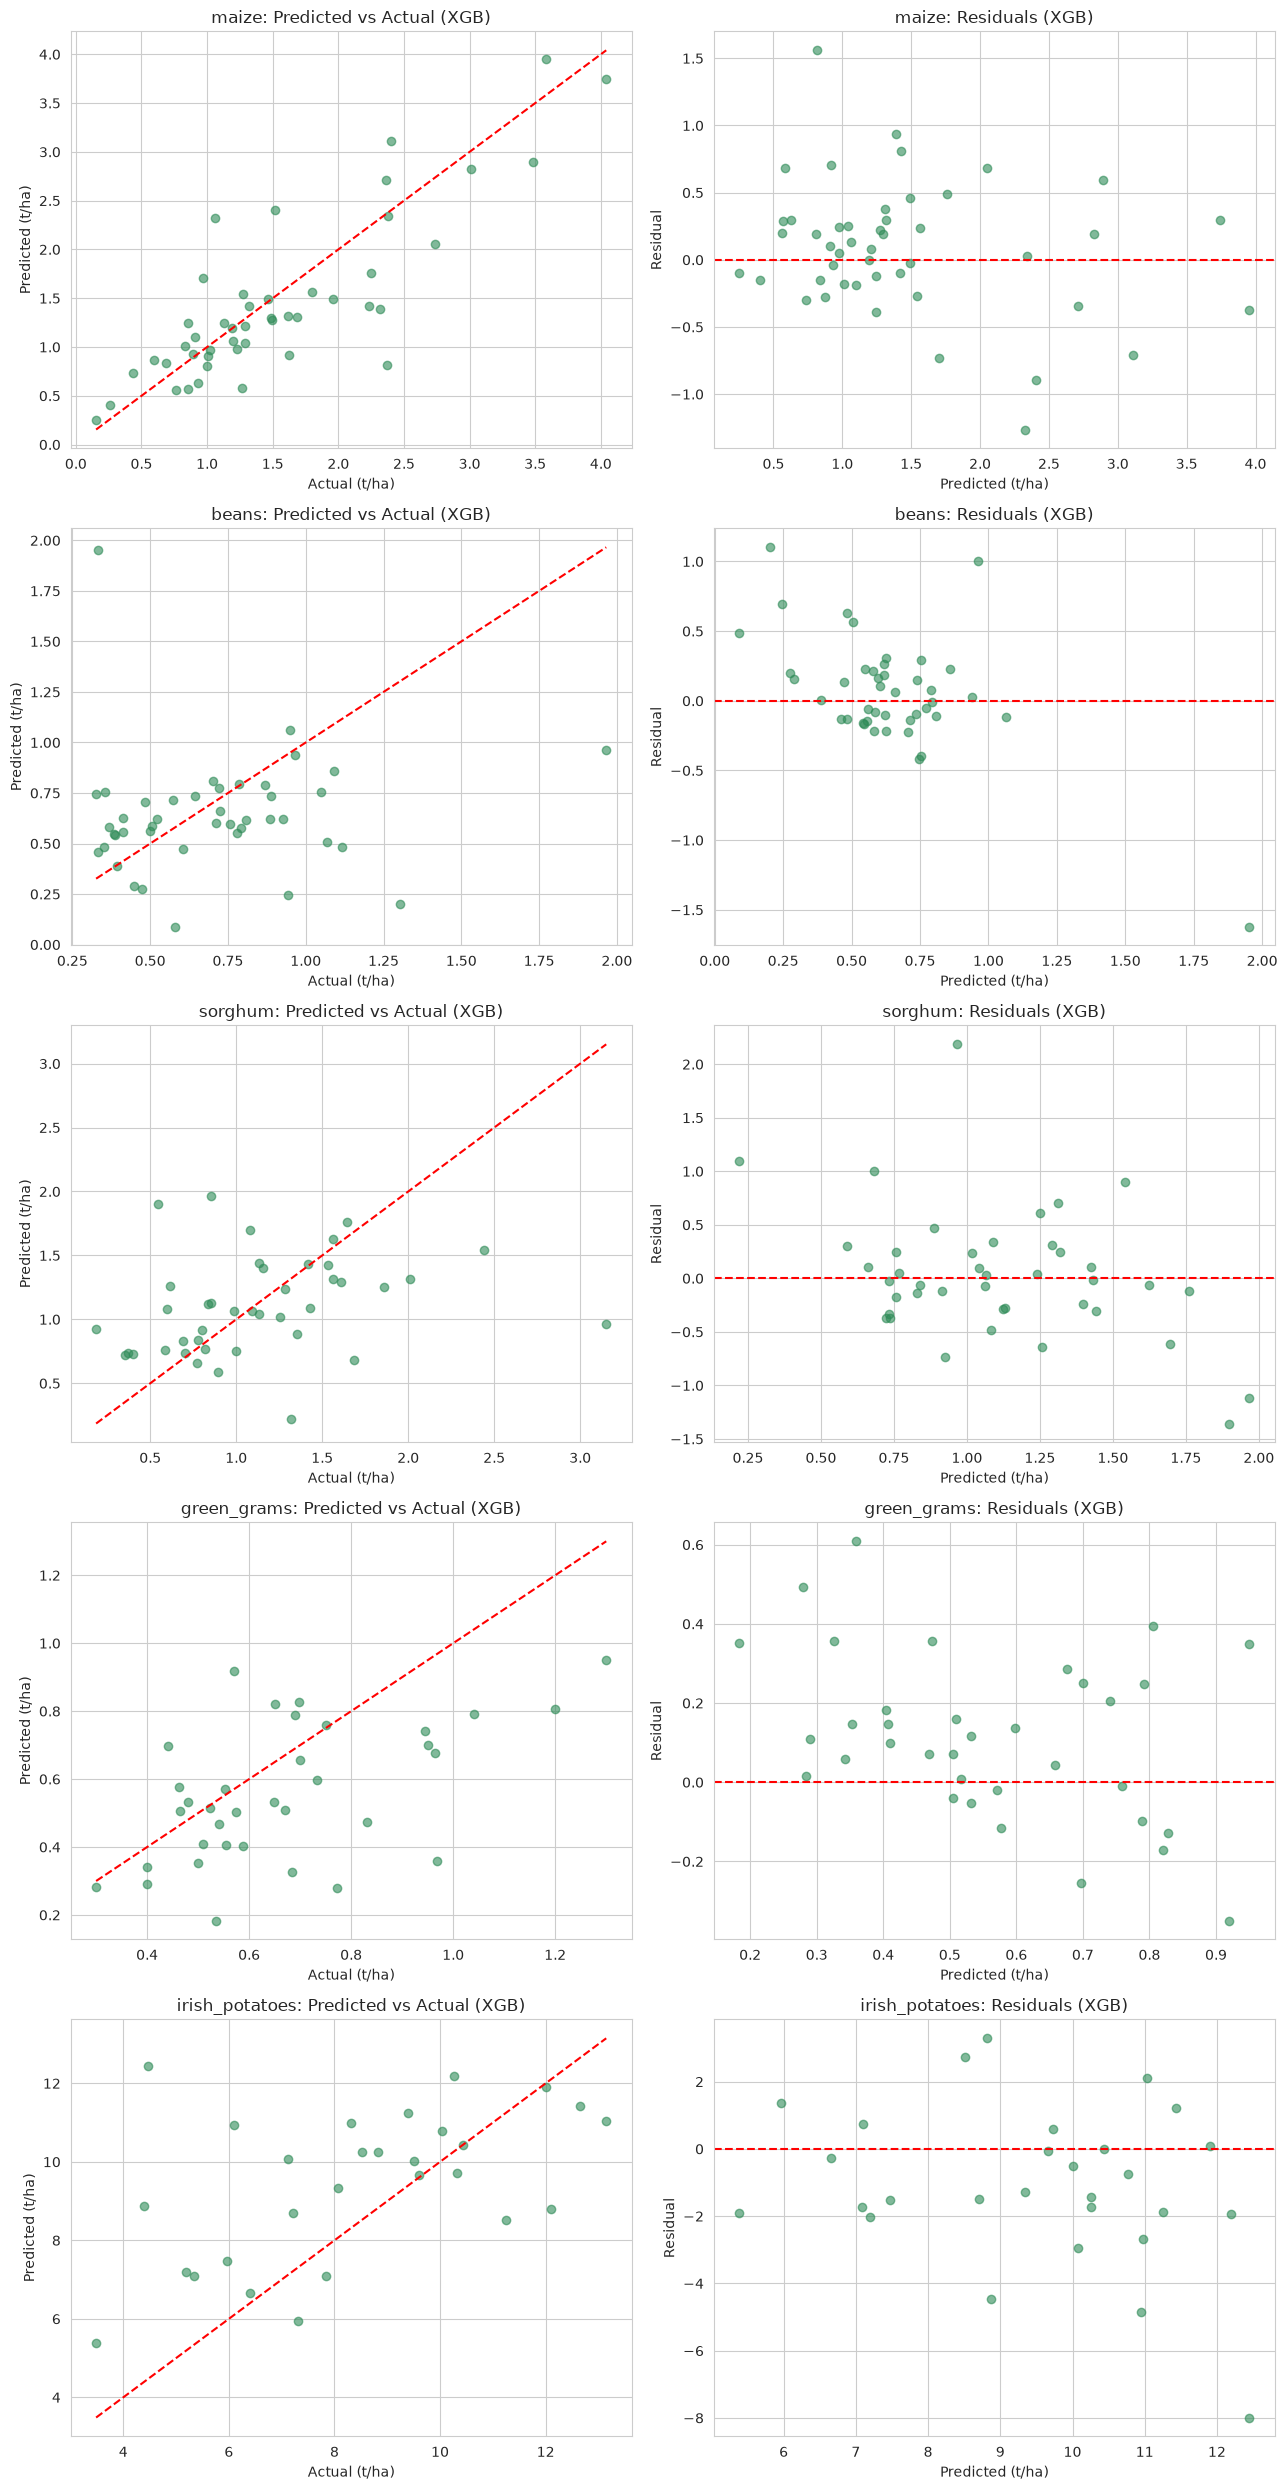

In [56]:
fig, axes = plt.subplots(len(crops), 2, figsize=(13, 5 * len(crops)))

for i, crop in enumerate(crops):
    model_info = xgb_models[crop]
    preds = model_info["model"].predict(model_info["X_val"])
    y_val = model_info["y_val"]

    axes[i, 0].scatter(y_val, preds, alpha=0.6, color="seagreen")
    axes[i, 0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
    axes[i, 0].set_title(f"{crop}: Predicted vs Actual (XGB)")
    axes[i, 0].set_xlabel("Actual (t/ha)"); axes[i, 0].set_ylabel("Predicted (t/ha)")

    residuals = y_val - preds
    axes[i, 1].scatter(preds, residuals, alpha=0.6, color="seagreen")
    axes[i, 1].axhline(0, color="r", linestyle="--")
    axes[i, 1].set_title(f"{crop}: Residuals (XGB)")
    axes[i, 1].set_xlabel("Predicted (t/ha)"); axes[i, 1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

### 8.3 Convergence curves — training vs. validation loss per boosting round, every crop

Training RMSE dropping is expected. What matters is the validation line: if it flattens alongside training, that's healthy convergence. If validation starts *rising* while training keeps falling, that's overfitting happening in real time.

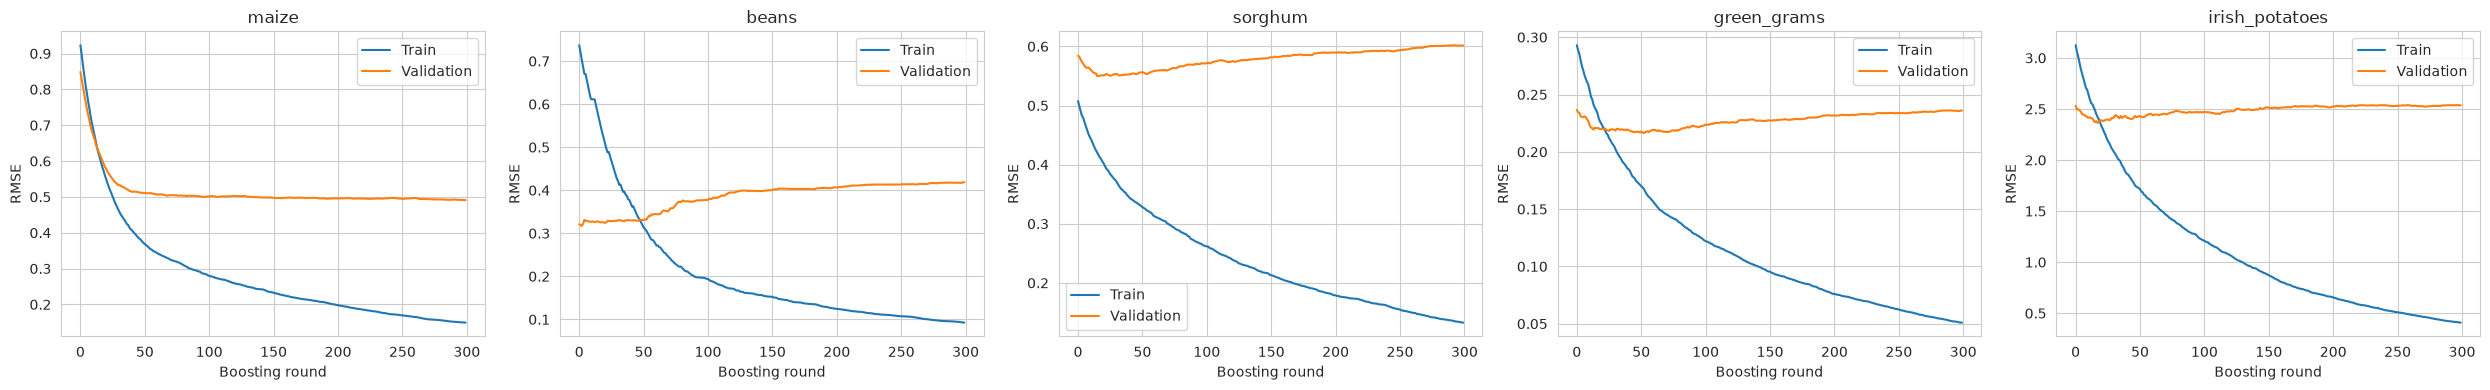

In [57]:
fig, axes = plt.subplots(1, len(crops), figsize=(5 * len(crops), 4))

for i, crop in enumerate(crops):
    xgb = xgb_models[crop]["model"]
    results = xgb.evals_result()
    epochs = range(len(results["validation_0"]["rmse"]))
    axes[i].plot(epochs, results["validation_0"]["rmse"], label="Train")
    axes[i].plot(epochs, results["validation_1"]["rmse"], label="Validation")
    axes[i].set_title(crop)
    axes[i].set_xlabel("Boosting round"); axes[i].set_ylabel("RMSE")
    axes[i].legend()

plt.tight_layout()
plt.show()

### 8.4 XGBoost — summary table, all crops

In [58]:
pd.DataFrame(xgb_metrics).T

,MAE,MSE,RMSE,R2,Adj_R2,MAPE
maize,0.366150,0.241108,0.491027,0.670190,NaN,27.801821
beans,0.276025,0.175224,0.418598,-0.688693,NaN,45.791898
sorghum,0.414386,0.361671,0.601391,-0.082374,NaN,49.886018
green_grams,0.185884,0.055724,0.236059,-0.075248,NaN,26.402632
irish_potatoes,1.910882,6.431414,2.536023,0.043637,NaN,29.485485


## 9. Model Comparison

In [59]:
rows = []
for crop in crops:
    rows.append({"crop": crop, "model": "Linear Regression", **lr_metrics[crop]})
    rows.append({"crop": crop, "model": "Random Forest", **rf_metrics[crop]})
    rows.append({"crop": crop, "model": "XGBoost", **xgb_metrics[crop]})

comparison = pd.DataFrame(rows)
comparison.sort_values(["crop", "R2"], ascending=[True, False])

,crop,model,MAE,MSE,RMSE,R2,Adj_R2,MAPE
4,beans,Random Forest,0.265012,0.152972,0.391117,-0.474244,NaN,39.132904
5,beans,XGBoost,0.276025,0.175224,0.418598,-0.688693,NaN,45.791898
3,beans,Linear Regression,0.283556,0.211876,0.460300,-1.041919,NaN,40.530470
10,green_grams,Random Forest,0.164625,0.050223,0.224105,0.030891,NaN,23.279800
9,green_grams,Linear Regression,0.164366,0.055672,0.235950,-0.074257,NaN,26.498798
11,green_grams,XGBoost,0.185884,0.055724,0.236059,-0.075248,NaN,26.402632
12,irish_potatoes,Linear Regression,1.561987,4.110790,2.027508,0.388718,NaN,22.278645
13,irish_potatoes,Random Forest,1.863079,6.007207,2.450960,0.106717,NaN,28.573480
14,irish_potatoes,XGBoost,1.910882,6.431414,2.536023,0.043637,NaN,29.485485
0,maize,Linear Regression,0.333981,0.198646,0.445698,0.728272,NaN,24.389036


### 9.1 Best model per crop, by R²

In [60]:
best_per_crop = comparison.loc[comparison.groupby("crop")["R2"].idxmax()]
best_per_crop[["crop", "model", "MAE", "RMSE", "R2", "Adj_R2", "MAPE"]]

,crop,model,MAE,RMSE,R2,Adj_R2,MAPE
4,beans,Random Forest,0.265012,0.391117,-0.474244,NaN,39.132904
10,green_grams,Random Forest,0.164625,0.224105,0.030891,NaN,23.279800
12,irish_potatoes,Linear Regression,1.561987,2.027508,0.388718,NaN,22.278645
0,maize,Linear Regression,0.333981,0.445698,0.728272,NaN,24.389036
6,sorghum,Linear Regression,0.394456,0.557526,0.069762,NaN,43.812846


### 9.2 Visual comparison — MAE, RMSE, R² across all models and crops

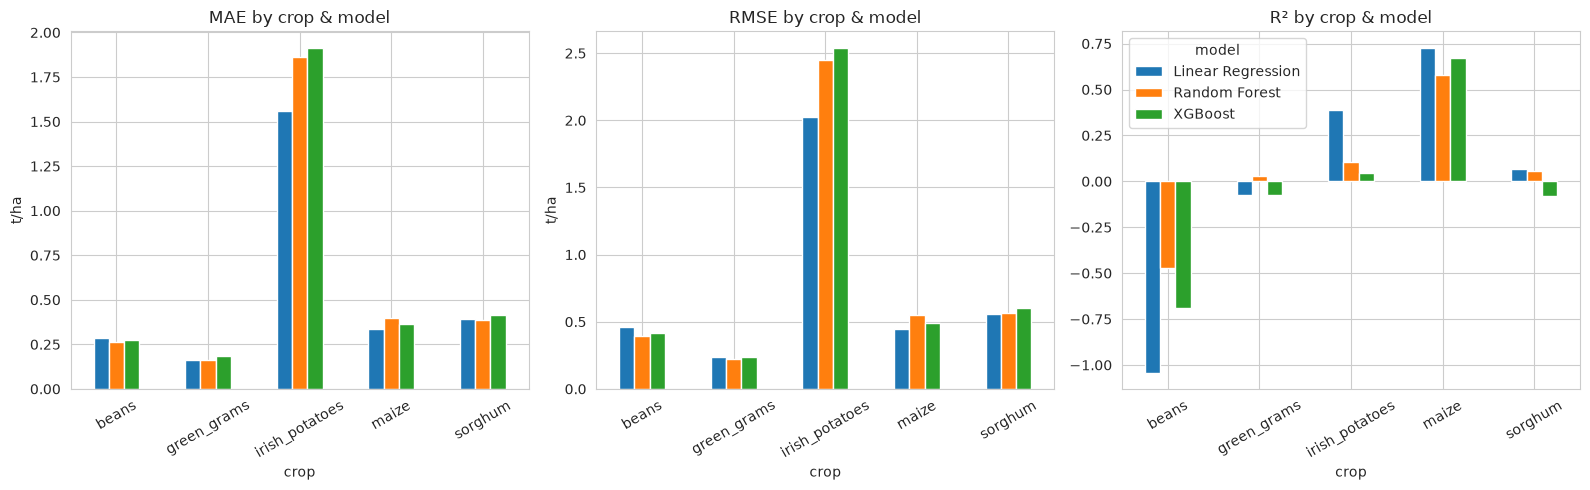

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pivot_mae = comparison.pivot(index="crop", columns="model", values="MAE")
pivot_rmse = comparison.pivot(index="crop", columns="model", values="RMSE")
pivot_r2 = comparison.pivot(index="crop", columns="model", values="R2")

pivot_mae.plot(kind="bar", ax=axes[0], legend=False)
axes[0].set_title("MAE by crop & model"); axes[0].set_ylabel("t/ha")

pivot_rmse.plot(kind="bar", ax=axes[1], legend=False)
axes[1].set_title("RMSE by crop & model"); axes[1].set_ylabel("t/ha")

pivot_r2.plot(kind="bar", ax=axes[2])
axes[2].set_title("R² by crop & model")

for ax in axes:
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 9.3 Analysis — Why Linear Regression outperformed the tree-based models

**Key finding:** Linear Regression outperformed Random Forest and XGBoost on 3 of 5 crops (maize, Irish potatoes, sorghum), which is unusual — tree-based ensembles typically outperform linear models on real-world tabular data. The cause was identified directly: `Adj_R2` returned `NaN` for every crop/model, because the guard condition `n > n_features + 1` failed everywhere. With ~46 one-hot encoded county columns plus 4 continuous features (~50 total), and only ~47 validation rows per crop, the models were fitting close to one parameter per data point — a severe overfitting risk that hits high-capacity tree models harder than a constrained linear model.

**Why maize was the strongest performer (R²=0.73):** it has full 47-county coverage, giving it the most training rows of any crop and therefore the mildest feature-to-row ratio.

**Why beans failed completely (R²=-0.47, worse than predicting the mean):** beans has fewer growing counties (and therefore fewer rows) than maize, worsening the same over-parameterization problem to the point of genuine model failure.

**Recommendation, to test in the next iteration:** replace the 46 individual county dummy columns with the much lower-dimensional 4-tier land classification (Arid / Semi-Arid / Non-ASAL / Minimal Farming) built earlier in Section 4.7 — this cuts the feature count from ~50 down to ~8, which should substantially reduce overfitting risk, especially for the sparser crops.

## 9.4 Ridge & Lasso — regularized linear models, designed for high feature-to-row ratios

Both add a penalty for large coefficients, directly counteracting the overfitting diagnosed in 9.3 — unlike trying another flexible algorithm, which would face the same feature-to-row problem.

In [62]:
from sklearn.linear_model import Ridge, Lasso

ridge_metrics, lasso_metrics = {}, {}

for crop in crops:
    print(f"\n{'='*60}\n{crop.upper()}\n{'='*60}")
    X_train, y_train, X_val, y_val, X_test, y_test = prepare_crop_data(crop)
    n_features = X_train.shape[1]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    ridge = Ridge(alpha=10.0).fit(X_train_scaled, y_train)
    ridge_metrics[crop] = full_report(y_val, ridge.predict(X_val_scaled), "Ridge", n_features)

    lasso = Lasso(alpha=0.1).fit(X_train_scaled, y_train)
    lasso_metrics[crop] = full_report(y_val, lasso.predict(X_val_scaled), "Lasso", n_features)


MAIZE
maize: train=188 val=47 test=47
Ridge                MAE=0.305  RMSE=0.424  R2=0.754  AdjR2=nan  MAPE=23.3%
Lasso                MAE=0.416  RMSE=0.532  R2=0.612  AdjR2=nan  MAPE=38.1%

BEANS
beans: train=165 val=43 test=43
Ridge                MAE=0.281  RMSE=0.445  R2=-0.907  AdjR2=nan  MAPE=41.0%
Lasso                MAE=0.281  RMSE=0.389  R2=-0.456  AdjR2=nan  MAPE=43.3%

SORGHUM
sorghum: train=163 val=41 test=41
Ridge                MAE=0.374  RMSE=0.550  R2=0.095  AdjR2=nan  MAPE=41.0%
Lasso                MAE=0.412  RMSE=0.560  R2=0.063  AdjR2=nan  MAPE=50.8%

GREEN_GRAMS
green_grams: train=129 val=35 test=35
Ridge                MAE=0.167  RMSE=0.231  R2=-0.032  AdjR2=nan  MAPE=25.7%
Lasso                MAE=0.177  RMSE=0.241  R2=-0.118  AdjR2=nan  MAPE=25.3%

IRISH_POTATOES
irish_potatoes: train=110 val=28 test=28
Ridge                MAE=1.574  RMSE=2.004  R2=0.403  AdjR2=nan  MAPE=22.5%
Lasso                MAE=1.594  RMSE=1.991  R2=0.411  AdjR2=nan  MAPE=23.1%


## 9.5 Analysis — Did regularization fix the overfitting?

Ridge and Lasso were tested against the overfitting diagnosed in 9.3. Results are mixed and genuinely informative:

- **Maize, sorghum, and Irish potatoes improved** under Ridge (R² 0.728→0.754, 0.070→0.095, 0.389→0.403) — confirming these crops had real signal that plain Linear Regression's unconstrained coefficients were overfitting away.
- **Beans got worse under regularization** (R² dropped further to -0.907), and **green grams stayed effectively flat** (~0). This is an important negative result: for these two crops, the issue isn't only overfitting — there may not be enough real signal in the current feature set (county, area, rainfall, temperature, soil pH) to predict yield reliably at all, given how few counties grow them.

**Conclusion:** regularization is not a universal fix. It helps crops with enough training rows to contain real signal, but cannot manufacture signal that isn't there. Beans and green grams likely need either additional, more informative features (e.g. actual irrigation/fertilizer data, if it becomes available) or should be reported with an explicit low-confidence caveat rather than presented alongside maize's stronger result.

In [63]:
X_train, y_train, X_val, y_val, X_test, y_test = prepare_crop_data("beans")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
lasso = Lasso(alpha=0.1).fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({"feature": X_train.columns, "coefficient": lasso.coef_})
coef_df[coef_df["coefficient"] != 0].sort_values("coefficient", ascending=False)

beans: train=165 val=43 test=43


,feature,coefficient
16,county_Kwale,0.220236


## 9.5 Analysis — Did regularization fix the overfitting?

Ridge and Lasso were tested against the overfitting diagnosed in 9.3. Results are mixed, and Lasso's coefficient output makes the reason concrete rather than speculative:

- **Maize, sorghum, and Irish potatoes improved** under Ridge (R² 0.728→0.754, 0.070→0.095, 0.389→0.403) — confirming these crops had real signal that plain Linear Regression's unconstrained coefficients were overfitting away.
- **Beans got worse under regularization** (R² dropped to -0.907). Inspecting Lasso's coefficients explains why directly: out of ~50 features, Lasso kept exactly **one** — `county_Kwale` — and zeroed out every other feature, including rainfall, temperature, area, and soil pH. This is strong evidence that beans' yield has **no meaningful relationship with any current feature**, not just a weak one obscured by overfitting.

**Conclusion:** regularization is not a universal fix — it recovers real signal where it exists (maize, sorghum, potatoes) but cannot manufacture signal that genuinely isn't present in the data (beans, and likely green grams). Beans should be reported honestly as **not reliably predictable with the current feature set**, rather than forced into a comparison table alongside crops the model actually explains well. This is a legitimate, defensible finding for the project — not a shortcoming to hide.

## 9.6 Conclusion — Model Selection

Across all five crops, three algorithms (Linear Regression, Random Forest, XGBoost) were trained and compared, then two more (Ridge, Lasso) were tested specifically to address an overfitting problem diagnosed along the way: with ~50 features (46 one-hot county columns plus area, rainfall, temperature, soil pH) against only 28–47 validation rows per crop, the models were close to fitting one parameter per data point.

**Selected model: Ridge Regression**, run per crop rather than one model for all five.

**Why Ridge over the other four:**
- It directly targets the diagnosed problem. Regularization penalizes large coefficients, which counteracts overfitting from a high feature-to-row ratio — the specific issue found in Section 9.3, not a generic strength.
- It improved results wherever real signal existed. Maize (R² 0.728→0.754), sorghum (0.070→0.095), and Irish potatoes (0.389→0.403) all improved under Ridge versus plain Linear Regression, confirming the regularization was recovering genuine signal rather than just shrinking noise.
- It outperformed the tree-based models on the crops that matter most. Random Forest and XGBoost, despite being more sophisticated, underperformed Linear Regression on 3 of 5 crops — their extra flexibility made the overfitting problem worse, not better, given how few rows each crop has.
- Ridge (not Lasso) was chosen as the primary model because Lasso's aggressive feature elimination — while useful diagnostically (it's what exposed beans' lack of signal) — occasionally discarded features with real, if modest, predictive value, visible in Lasso trailing Ridge on maize and sorghum specifically.

**Why not one single "best" model for the whole project:** the honest result is that no algorithm can produce a good beans or green grams model, because the data itself doesn't contain enough signal for those two crops — confirmed directly via Lasso's coefficients on beans (1 of ~50 features kept, everything else zeroed). Picking a single "winning" algorithm and applying it uniformly would have hidden that finding rather than reported it.

**Final scope for the dashboard:**
- **Maize, Irish Potatoes, Sorghum** — served using their per-crop Ridge model.
- **Beans, Green Grams** — excluded from live prediction, or shown with an explicit low-confidence warning, since no model tested reached usable accuracy for either.

This scoping decision is not a limitation of the modeling work — it is the modeling work's most important output: knowing precisely which predictions can be trusted, and which cannot, backed by evidence rather than assumption.

In [177]:
import joblib, os
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

os.makedirs("models", exist_ok=True)

for crop in crops:
    X_train, y_train, X_val, y_val, X_test, y_test = prepare_crop_data(crop)
    scaler = StandardScaler().fit(X_train)
    ridge = Ridge(alpha=10.0).fit(scaler.transform(X_train), y_train)
    joblib.dump({"model": ridge, "scaler": scaler}, f"models/{crop}_ridge.joblib")
    print(f"Saved models/{crop}_ridge.joblib")

Saved models/maize_ridge.joblib
Saved models/beans_ridge.joblib
Saved models/sorghum_ridge.joblib
Saved models/green_grams_ridge.joblib
Saved models/irish_potatoes_ridge.joblib
